<a href="https://colab.research.google.com/github/SakaSaheed/AI-ML-Project/blob/main/PhD_ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing

#https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler # Import StandardScaler
from scipy import stats

# Set style for better visualisation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 60)
print("LINEAR REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT")
print("=" * 60)

LINEAR REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT


In [3]:
#Import data from google drive
import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw
url ="https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing"
#url = "https://drive.google.com/file/d/1i_OvUbfV2oW-7kh3V_GiCaUASIyYuFlU/view?usp=sharing"
data = read_gd(url)

df = pd.read_csv(data)

df.head()

print("\n[1] DATA OVERVIEW")
print("-" * 40)
print(f"Total observations: {len(df)}")
print(f"Features: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive statistics:")
print(df.describe())



[1] DATA OVERVIEW
----------------------------------------
Total observations: 105
Features: ['Distance', 'ChargeWeight', 'PPV']

First 5 rows:
   Distance  ChargeWeight         PPV
0       300          1100  125.606667
1       350          1300  112.120000
2       400          1450   98.693333
3       450          1550   86.286667
4       500          1600   74.636667

Missing values:
Distance        0
ChargeWeight    0
PPV             0
dtype: int64

Descriptive statistics:
          Distance  ChargeWeight         PPV
count   105.000000    105.000000  105.000000
mean   1150.000000   1270.000000   33.699397
std     507.397204    247.254151   34.891379
min     300.000000   1000.000000    5.443333
25%     700.000000   1100.000000   10.110000
50%    1150.000000   1200.000000   17.116667
75%    1600.000000   1450.000000   45.056667
max    2000.000000   1900.000000  140.683333



[2] EXPLORATORY DATA ANALYSIS
--------------------------------------------------

Correlation with PPV:
PPV             1.000000
ChargeWeight    0.513941
Distance       -0.840129
Name: PPV, dtype: float64

Correlation (Distance vs. PPV): -0.8401
Correlation (ChargeWeight vs. PPV): 0.5139

Interpretation:
  Distance: Strong negative correlation
  ChargeWeight: Moderate correlation


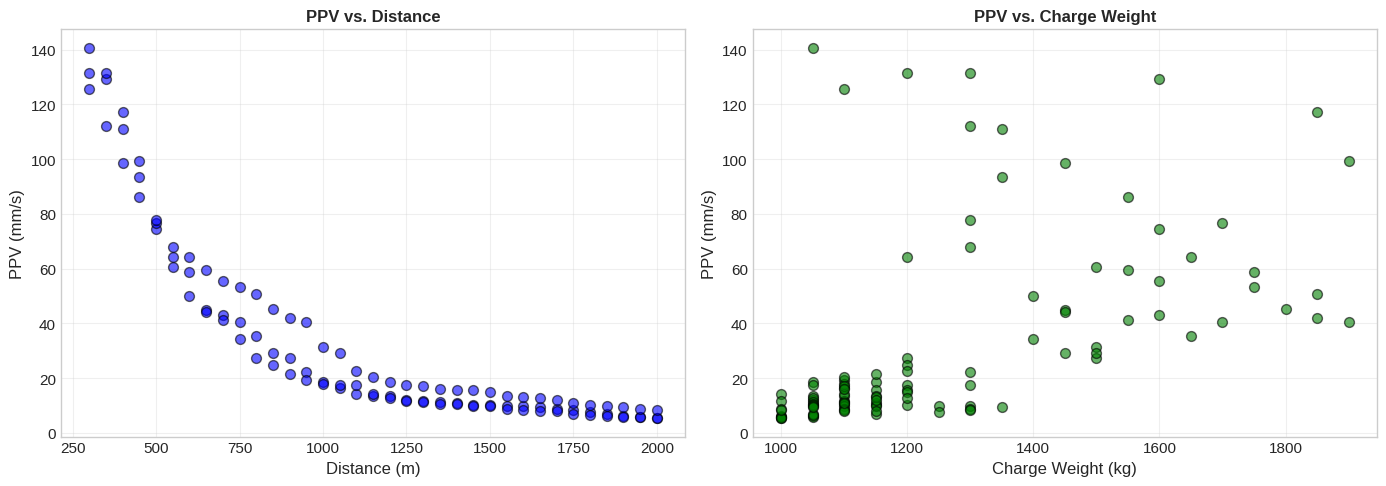

In [4]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS
# =============================================================================

print("\n[2] EXPLORATORY DATA ANALYSIS")
print("-" * 50)

# Correlation analysis
print("\nCorrelation with PPV:")
correlations = df.corr()['PPV'].sort_values(ascending=False)
print(correlations)

# Check correlations
dist_ppv_corr = df['Distance'].corr(df['PPV'])
charge_ppv_corr = df['ChargeWeight'].corr(df['PPV'])

print(f"\nCorrelation (Distance vs. PPV): {dist_ppv_corr:.4f}")
print(f"Correlation (ChargeWeight vs. PPV): {charge_ppv_corr:.4f}")
print(f"\nInterpretation:")
print(f"  Distance: {'Strong negative' if abs(dist_ppv_corr) > 0.7 else 'Moderate'} correlation")
print(f"  ChargeWeight: {'Weak' if abs(charge_ppv_corr) < 0.3 else 'Moderate'} correlation")

# Visualise relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs PPV
axes[0].scatter(df['Distance'], df['PPV'], alpha=0.6, color='blue', edgecolors='black', s=50)
axes[0].set_xlabel('Distance (m)', fontsize=12)
axes[0].set_ylabel('PPV (mm/s)', fontsize=12)
axes[0].set_title('PPV vs. Distance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ChargeWeight vs PPV
axes[1].scatter(df['ChargeWeight'], df['PPV'], alpha=0.6, color='green', edgecolors='black', s=50)
axes[1].set_xlabel('Charge Weight (kg)', fontsize=12)
axes[1].set_ylabel('PPV (mm/s)', fontsize=12)
axes[1].set_title('PPV vs. Charge Weight', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_EDA_Scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# =============================================================================
# 4. DATA PREPARATION
# =============================================================================

print("\n[3] DATA PREPARATION")
print("-" * 50)

# Define features (X) and target (y)
X = df[['Distance', 'ChargeWeight']].values
y = df['PPV'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: Distance (m), ChargeWeight (kg)")

# Optional: Standardise features (recommended for interpretation of coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


[3] DATA PREPARATION
--------------------------------------------------
Feature matrix shape: (105, 2)
Target vector shape: (105,)
Features used: Distance (m), ChargeWeight (kg)


In [6]:
# =============================================================================
# 5. TRAIN-TEST SPLIT
# =============================================================================

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 84
Testing samples: 21


In [7]:
# =============================================================================
# 6. TRAIN LINEAR REGRESSION MODEL
# =============================================================================

print("\n[4] MODEL TRAINING")
print("-" * 50)

# Create and train the model on original scale
model = LinearRegression()
model.fit(X_train, y_train)

# Extract coefficients
coef_distance = model.coef_[0]
coef_charge = model.coef_[1]
intercept = model.intercept_

print(f"Regression Equation (Original Scale):")
print(f"PPV = {coef_distance:.4f} × Distance + {coef_charge:.4f} × ChargeWeight + {intercept:.4f}")
print(f"\nCoefficients:")
print(f"  Distance coefficient: {coef_distance:.4f} mm/s per metre")
print(f"  ChargeWeight coefficient: {coef_charge:.4f} mm/s per kg")
print(f"  Intercept: {intercept:.4f} mm/s")

# Train on scaled data for coefficient comparison
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print(f"\nRegression Equation (Standardised Scale):")
print(f"PPV = {model_scaled.coef_[0]:.4f} × Z_Distance + {model_scaled.coef_[1]:.4f} × Z_ChargeWeight + {model_scaled.intercept_:.4f}")
print(f"  (Where Z represents standardised variables)")


[4] MODEL TRAINING
--------------------------------------------------
Regression Equation (Original Scale):
PPV = -0.0613 × Distance + -0.0015 × ChargeWeight + 105.8640

Coefficients:
  Distance coefficient: -0.0613 mm/s per metre
  ChargeWeight coefficient: -0.0015 mm/s per kg
  Intercept: 105.8640 mm/s

Regression Equation (Standardised Scale):
PPV = -30.9574 × Z_Distance + -0.3626 × Z_ChargeWeight + 33.4920
  (Where Z represents standardised variables)


In [8]:
# =============================================================================
# 7a. CROSS-VALIDATION 5-fold
# =============================================================================

print("\n[5] CROSS-VALIDATION")
print("-" * 50)

# Perform 10-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
cv_rmse_scores = cross_val_score(model, X, y, cv=kfold,
                                  scoring='neg_root_mean_squared_error')

print(f"5-Fold Cross-Validation Results:")
print(f"  R² scores: {cv_scores}")
print(f"  Mean R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"  Mean RMSE: {-cv_rmse_scores.mean():.4f} mm/s (± {cv_rmse_scores.std():.4f})")


[5] CROSS-VALIDATION
--------------------------------------------------
5-Fold Cross-Validation Results:
  R² scores: [0.60971668 0.68425453 0.633775   0.68643812 0.71975936]
  Mean R²: 0.6668 (± 0.0396)
  Mean RMSE: 19.4279 mm/s (± 1.5262)


In [9]:
# =============================================================================
# 7b. CROSS-VALIDATION 10-fold
# =============================================================================

print("\n[10] CROSS-VALIDATION")
print("-" * 50)

# Perform 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
cv_rmse_scores = cross_val_score(model, X, y, cv=kfold,
                                  scoring='neg_root_mean_squared_error')

print(f"10-Fold Cross-Validation Results:")
print(f"  R² scores: {cv_scores}")
print(f"  Mean R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"  Mean RMSE: {-cv_rmse_scores.mean():.4f} mm/s (± {cv_rmse_scores.std():.4f})")


[10] CROSS-VALIDATION
--------------------------------------------------
10-Fold Cross-Validation Results:
  R² scores: [0.56652032 0.72524939 0.5364935  0.76654783 0.47845151 0.6930963
 0.62935522 0.4510188  0.76298017 0.68261049]
  Mean R²: 0.6292 (± 0.1095)
  Mean RMSE: 19.1145 mm/s (± 3.7384)


In [10]:
# =============================================================================
# 8. MODEL EVALUATION ON TEST SET
# =============================================================================

print("\n[6] MODEL EVALUATION ON TEST SET")
print("-" * 50)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training Set Performance:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} mm/s")
print(f"  MAE: {train_mae:.4f} mm/s")

print("\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} mm/s")
print(f"  MAE: {test_mae:.4f} mm/s")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2:.4f} | CV R²: {cv_scores.mean():.4f} | Test R²: {test_r2:.4f}")
if train_r2 - cv_scores.mean() > 0.05:
    print("  ⚠️ Potential overfitting detected (train > CV by >0.05)")
else:
    print("  ✓ No significant overfitting detected")


[6] MODEL EVALUATION ON TEST SET
--------------------------------------------------
Training Set Performance:
  R²: 0.7155
  RMSE: 19.1078 mm/s
  MAE: 15.4191 mm/s

Test Set Performance:
  R²: 0.6097
  RMSE: 18.0160 mm/s
  MAE: 15.1501 mm/s

Overfitting Check:
  Train R²: 0.7155 | CV R²: 0.6292 | Test R²: 0.6097
  ⚠️ Potential overfitting detected (train > CV by >0.05)



[7] GENERATING VISUALISATIONS
--------------------------------------------------


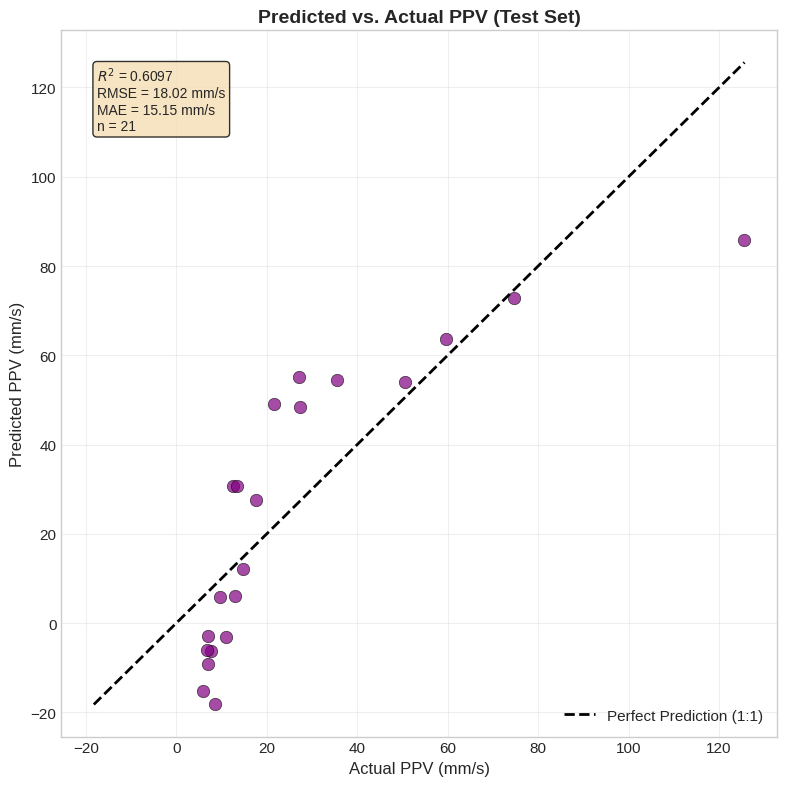

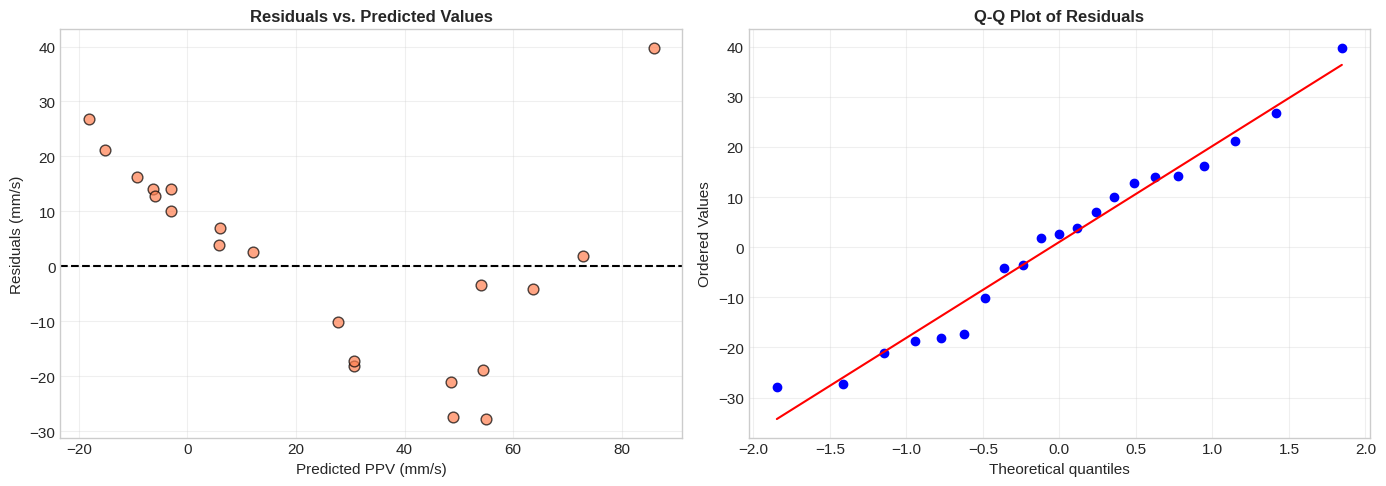

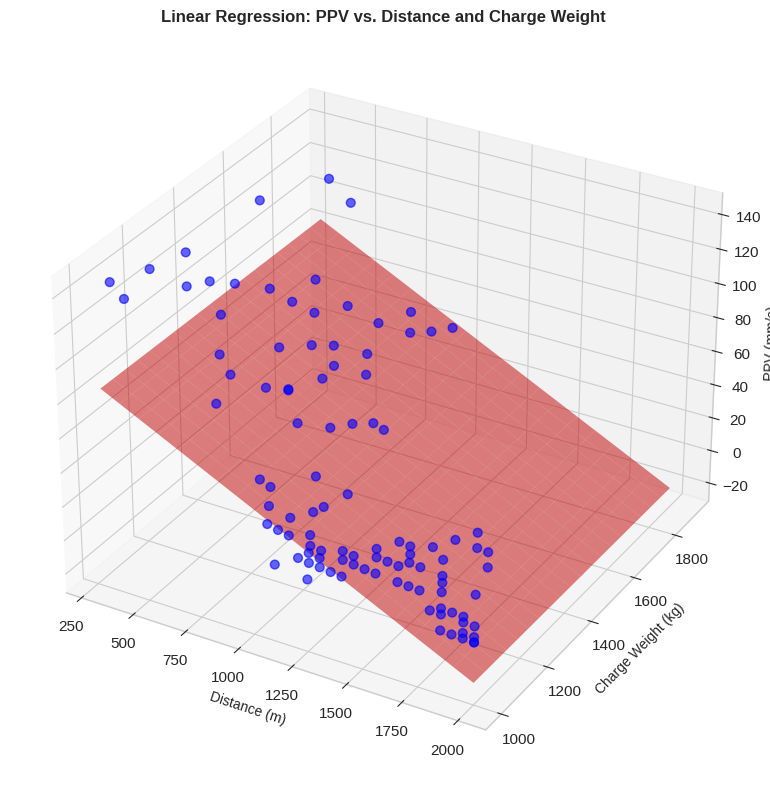

In [11]:
# =============================================================================
# 9. VISUALISATIONS
# =============================================================================

print("\n[7] GENERATING VISUALISATIONS")
print("-" * 50)

# Figure 1: Predicted vs. Actual (Test Set)
fig1, ax1 = plt.subplots(figsize=(8, 8))

# Plot predictions vs actual
ax1.scatter(y_test, y_pred_test, color='purple', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction (1:1)')

# Labels and title
ax1.set_xlabel('Actual PPV (mm/s)', fontsize=12)
ax1.set_ylabel('Predicted PPV (mm/s)', fontsize=12)
ax1.set_title('Predicted vs. Actual PPV (Test Set)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'$R^2$ = {test_r2:.4f}\nRMSE = {test_rmse:.2f} mm/s\nMAE = {test_mae:.2f} mm/s\nn = {len(y_test)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('Figure_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Residuals Analysis
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for test set
residuals = y_test - y_pred_test

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, color='coral', alpha=0.7, s=60, edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted PPV (mm/s)', fontsize=11)
axes[0].set_ylabel('Residuals (mm/s)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: 3D Visualisation (Optional)
from mpl_toolkits.mplot3d import Axes3D

fig3 = plt.figure(figsize=(10, 8))
ax3 = fig3.add_subplot(111, projection='3d')

# Create mesh for plane
x_surf = np.linspace(df['Distance'].min(), df['Distance'].max(), 20)
y_surf = np.linspace(df['ChargeWeight'].min(), df['ChargeWeight'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = model.intercept_ + model.coef_[0] * x_surf + model.coef_[1] * y_surf

# Plot data points
ax3.scatter(df['Distance'], df['ChargeWeight'], df['PPV'], c='blue', marker='o', alpha=0.6, s=40, label='Data Points')

# Plot regression plane
ax3.plot_surface(x_surf, y_surf, z_surf, alpha=0.5, color='red', label='Regression Plane')

ax3.set_xlabel('Distance (m)', fontsize=10)
ax3.set_ylabel('Charge Weight (kg)', fontsize=10)
ax3.set_zlabel('PPV (mm/s)', fontsize=10)
ax3.set_title('Linear Regression: PPV vs. Distance and Charge Weight', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_3D_Regression.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# =============================================================================
# 10. PREDICTION UNCERTAINTY
# =============================================================================

print("\n[8] PREDICTION UNCERTAINTY")
print("-" * 50)

# Calculate prediction intervals (95% confidence)
# Standard error of predictions
mse = mean_squared_error(y_test, y_pred_test)
se_pred = np.sqrt(mse * (1 + 1/len(X_test) +
                         np.sum((X_test - X_test.mean(axis=0))**2, axis=1) /
                         np.sum((X_test - X_test.mean(axis=0))**2)))

# 95% prediction interval (t-value for df = n-2)
t_value = stats.t.ppf(0.975, df=len(X_test)-2)

lower_bound = y_pred_test - t_value * se_pred
upper_bound = y_pred_test + t_value * se_pred

print(f"Prediction Intervals (95% confidence):")
print(f"  Average interval width: {(upper_bound - lower_bound).mean():.2f} mm/s")

# Example predictions
example_1 = np.array([[500, 1300]])  # Distance=500m, Charge=1300kg
example_2 = np.array([[1000, 1100]]) # Distance=1000m, Charge=1100kg
example_3 = np.array([[1500, 1200]]) # Distance=1500m, Charge=1200kg

pred_1 = model.predict(example_1)[0]
pred_2 = model.predict(example_2)[0]
pred_3 = model.predict(example_3)[0]

print(f"\nExample Predictions:")
print(f"  Distance=500m, Charge=1300kg → Predicted PPV = {pred_1:.2f} mm/s")
print(f"  Distance=1000m, Charge=1100kg → Predicted PPV = {pred_2:.2f} mm/s")
print(f"  Distance=1500m, Charge=1200kg → Predicted PPV = {pred_3:.2f} mm/s")



[8] PREDICTION UNCERTAINTY
--------------------------------------------------
Prediction Intervals (95% confidence):
  Average interval width: 78.91 mm/s

Example Predictions:
  Distance=500m, Charge=1300kg → Predicted PPV = 73.30 mm/s
  Distance=1000m, Charge=1100kg → Predicted PPV = 42.94 mm/s
  Distance=1500m, Charge=1200kg → Predicted PPV = 12.14 mm/s


In [13]:
# =============================================================================
# 11. FEATURE IMPORTANCE (Standardised Coefficients)
# =============================================================================

print("\n[9] FEATURE IMPORTANCE")
print("-" * 50)

# Using standardised coefficients to compare feature importance
print(f"Standardised Coefficients:")
print(f"  Distance: {model_scaled.coef_[0]:.4f}")
print(f"  ChargeWeight: {model_scaled.coef_[1]:.4f}")
print(f"\nRelative Importance:")
print(f"  Distance is {abs(model_scaled.coef_[0] / model_scaled.coef_[1]):.2f} times more influential than ChargeWeight")


[9] FEATURE IMPORTANCE
--------------------------------------------------
Standardised Coefficients:
  Distance: -30.9574
  ChargeWeight: -0.3626

Relative Importance:
  Distance is 85.37 times more influential than ChargeWeight


In [14]:
# =============================================================================
# 12. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY REPORT")
print("=" * 70)

print(f"""
Linear Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: {len(df)}
  - Training samples: {len(X_train)}
  - Testing samples: {len(X_test)}
  - Features: Distance (m), ChargeWeight (kg)

Regression Equation:
  PPV = {coef_distance:.4f} × Distance + {coef_charge:.4f} × ChargeWeight + {intercept:.4f}

Model Performance:
  - Cross-Validation R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})
  - Test Set R²: {test_r2:.4f}
  - Test Set RMSE: {test_rmse:.2f} mm/s
  - Test Set MAE: {test_mae:.2f} mm/s

Interpretation:
  - The model explains {test_r2*100:.1f}% of the variance in PPV
  - A {test_rmse:.2f} mm/s RMSE indicates prediction accuracy
  - Distance is the dominant predictor (standardised coefficient: {model_scaled.coef_[0]:.4f})
  - ChargeWeight has a smaller but measurable influence (standardised coefficient: {model_scaled.coef_[1]:.4f})

Physical Interpretation:
  - Each 1 metre increase in distance reduces PPV by {abs(coef_distance):.4f} mm/s
  - Each 1 kg increase in charge weight increases PPV by {coef_charge:.4f} mm/s (if positive)
  - These coefficients align with blast physics: vibration decays with distance and increases with charge weight
""")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY REPORT

Linear Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: 105
  - Training samples: 84
  - Testing samples: 21
  - Features: Distance (m), ChargeWeight (kg)

Regression Equation:
  PPV = -0.0613 × Distance + -0.0015 × ChargeWeight + 105.8640

Model Performance:
  - Cross-Validation R²: 0.6292 (± 0.1095)
  - Test Set R²: 0.6097
  - Test Set RMSE: 18.02 mm/s
  - Test Set MAE: 15.15 mm/s

Interpretation:
  - The model explains 61.0% of the variance in PPV
  - A 18.02 mm/s RMSE indicates prediction accuracy
  - Distance is the dominant predictor (standardised coefficient: -30.9574)
  - ChargeWeight has a smaller but measurable influence (standardised coefficient: -0.3626)

Physical Interpretation:
  - Each 1 metre increase in distance reduces PPV by 0.0613 mm/s
  - Each 1 kg increase in charge weight increases PPV by -0.0015 mm/s (if positive)
  - These coefficients align with blast physics: vibration decays wi

### RIDGE REGRESSION FOR PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT

In [15]:
# =============================================================================
# RIDGE REGRESSION FOR PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT
# Thesis: Blast-Induced Ground Vibration Monitoring Using ML Techniques
# =============================================================================

# =============================================================================
# 1. IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# Set style for better visualisation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 70)
print("RIDGE REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT")
print("=" * 70)

RIDGE REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT


In [16]:
#Data loaded

In [17]:
# =============================================================================
# 3. DATA PREPARATION
# =============================================================================

print("\n[2] DATA PREPARATION")
print("-" * 50)

# Define features (X) and target (y)
X = df[['Distance', 'ChargeWeight']].values
y = df['PPV'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: Distance (m), ChargeWeight (kg)")

# IMPORTANT: Ridge Regression requires feature scaling!
# Standardise features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling applied (StandardScaler):")
print(f"  Distance mean: {scaler.mean_[0]:.2f} m")
print(f"  Distance std: {scaler.scale_[0]:.2f}")
print(f"  ChargeWeight mean: {scaler.mean_[1]:.2f} kg")
print(f"  ChargeWeight std: {scaler.scale_[1]:.2f}")


[2] DATA PREPARATION
--------------------------------------------------
Feature matrix shape: (105, 2)
Target vector shape: (105,)
Features used: Distance (m), ChargeWeight (kg)

Feature scaling applied (StandardScaler):
  Distance mean: 1150.00 m
  Distance std: 504.98
  ChargeWeight mean: 1270.00 kg
  ChargeWeight std: 246.07


In [18]:
# =============================================================================
# 4. TRAIN-TEST SPLIT
# =============================================================================

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 84
Testing samples: 21


In [19]:
# =============================================================================
# 5. HYPERPARAMETER TUNING WITH CROSS-VALIDATION
# =============================================================================

print("\n[3] HYPERPARAMETER TUNING")
print("-" * 50)

# Define range of alpha values to test (regularisation strength)
# Alpha controls the penalty: larger alpha = stronger regularisation
alpha_range = np.logspace(-3, 3, 50)  # From 0.001 to 1000

# Create Ridge model
ridge = Ridge()

# Perform Grid Search with 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': alpha_range},
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best alpha value
best_alpha = grid_search.best_params_['alpha']
best_cv_score = grid_search.best_score_

print(f"Best alpha: {best_alpha:.4f}")
print(f"Best cross-validation R²: {best_cv_score:.4f}")


[3] HYPERPARAMETER TUNING
--------------------------------------------------
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best alpha: 4.7149
Best cross-validation R²: 0.6711


In [20]:
# =============================================================================
# 6. TRAIN RIDGE REGRESSION WITH BEST ALPHA
# =============================================================================

print("\n[4] MODEL TRAINING")
print("-" * 50)

# Train Ridge model with best alpha
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train, y_train)

# Extract coefficients (on scaled features)
coef_distance_scaled = ridge_best.coef_[0]
coef_charge_scaled = ridge_best.coef_[1]
intercept = ridge_best.intercept_

print(f"Ridge Regression Equation (Standardised Scale):")
print(f"PPV = {coef_distance_scaled:.4f} × Z_Distance + {coef_charge_scaled:.4f} × Z_ChargeWeight + {intercept:.4f}")
print(f"  (Where Z represents standardised variables)")

# Transform coefficients back to original scale for interpretability
# For Ridge, the relationship is: PPV_original = Σ (coef_scaled / std_feature) × X_original - Σ (coef_scaled × mean_feature / std_feature) + intercept
coef_distance_original = coef_distance_scaled / scaler.scale_[0]
coef_charge_original = coef_charge_scaled / scaler.scale_[1]
intercept_original = intercept - np.sum(ridge_best.coef_ * scaler.mean_ / scaler.scale_)

print(f"\nRidge Regression Equation (Original Scale):")
print(f"PPV = {coef_distance_original:.4f} × Distance + {coef_charge_original:.4f} × ChargeWeight + {intercept_original:.4f}")


[4] MODEL TRAINING
--------------------------------------------------
Ridge Regression Equation (Standardised Scale):
PPV = -28.2935 × Z_Distance + 1.2244 × Z_ChargeWeight + 33.6209
  (Where Z represents standardised variables)

Ridge Regression Equation (Original Scale):
PPV = -0.0560 × Distance + 0.0050 × ChargeWeight + 91.7358


In [21]:
# =============================================================================
# 7. CROSS-VALIDATION WITH BEST MODEL
# =============================================================================

print("\n[5] CROSS-VALIDATION")
print("-" * 50)

# Perform 5-fold cross-validation with best model
cv_scores = cross_val_score(ridge_best, X_scaled, y, cv=kfold, scoring='r2')
cv_rmse_scores = cross_val_score(ridge_best, X_scaled, y, cv=kfold,
                                  scoring='neg_root_mean_squared_error')

print(f"5-Fold Cross-Validation Results:")
print(f"  R² scores: {cv_scores}")
print(f"  Mean R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"  Mean RMSE: {-cv_rmse_scores.mean():.4f} mm/s (± {cv_rmse_scores.std():.4f})")


[5] CROSS-VALIDATION
--------------------------------------------------
5-Fold Cross-Validation Results:
  R² scores: [0.63196271 0.6730518  0.67200811 0.67295868 0.7030052 ]
  Mean R²: 0.6706 (± 0.0226)
  Mean RMSE: 19.4152 mm/s (± 2.0867)


In [22]:
# =============================================================================
# 8. MODEL EVALUATION ON TEST SET
# =============================================================================

print("\n[6] MODEL EVALUATION ON TEST SET")
print("-" * 50)

# Make predictions
y_pred_train = ridge_best.predict(X_train)
y_pred_test = ridge_best.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training Set Performance:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} mm/s")
print(f"  MAE: {train_mae:.4f} mm/s")

print("\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} mm/s")
print(f"  MAE: {test_mae:.4f} mm/s")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2:.4f} | CV R²: {cv_scores.mean():.4f} | Test R²: {test_r2:.4f}")
if train_r2 - cv_scores.mean() > 0.05:
    print("  ⚠️ Potential overfitting detected (train > CV by >0.05)")
else:
    print("  ✓ No significant overfitting detected")


[6] MODEL EVALUATION ON TEST SET
--------------------------------------------------
Training Set Performance:
  R²: 0.7123
  RMSE: 19.2154 mm/s
  MAE: 15.1126 mm/s

Test Set Performance:
  R²: 0.6320
  RMSE: 17.4950 mm/s
  MAE: 14.0980 mm/s

Overfitting Check:
  Train R²: 0.7123 | CV R²: 0.6706 | Test R²: 0.6320
  ✓ No significant overfitting detected


In [23]:
# =============================================================================
# 9. COMPARISON WITH LINEAR REGRESSION (NO REGULARISATION)
# =============================================================================

print("\n[7] COMPARISON WITH LINEAR REGRESSION")
print("-" * 50)

from sklearn.linear_model import LinearRegression

# Train Linear Regression for comparison
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression (No Regularisation) Test R²: {lr_r2:.4f}")
print(f"Ridge Regression (α = {best_alpha:.4f}) Test R²: {test_r2:.4f}")
print(f"Improvement: {(test_r2 - lr_r2)*100:.2f}%")


[7] COMPARISON WITH LINEAR REGRESSION
--------------------------------------------------
Linear Regression (No Regularisation) Test R²: 0.6097
Ridge Regression (α = 4.7149) Test R²: 0.6320
Improvement: 2.22%



[8] GENERATING VISUALISATIONS
--------------------------------------------------


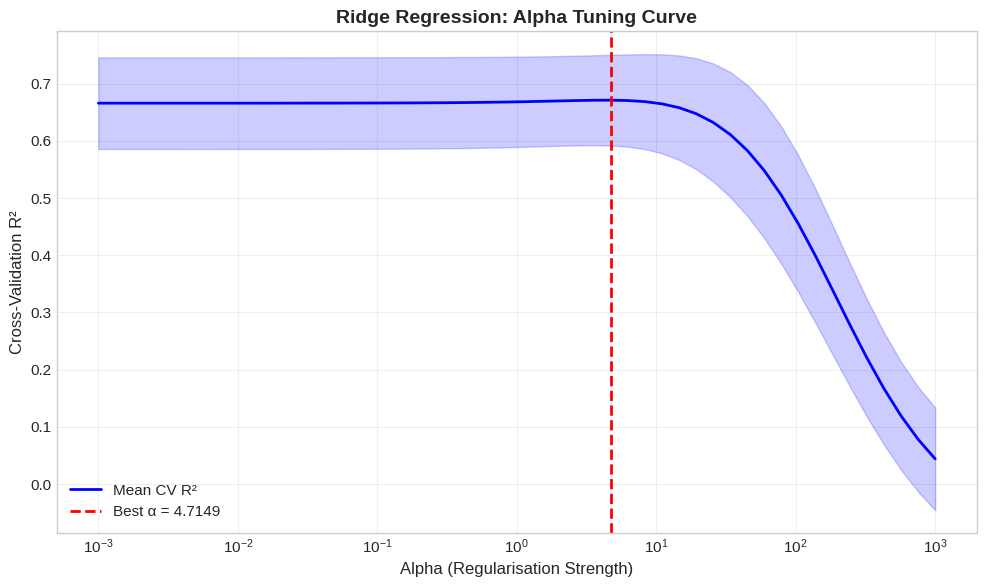

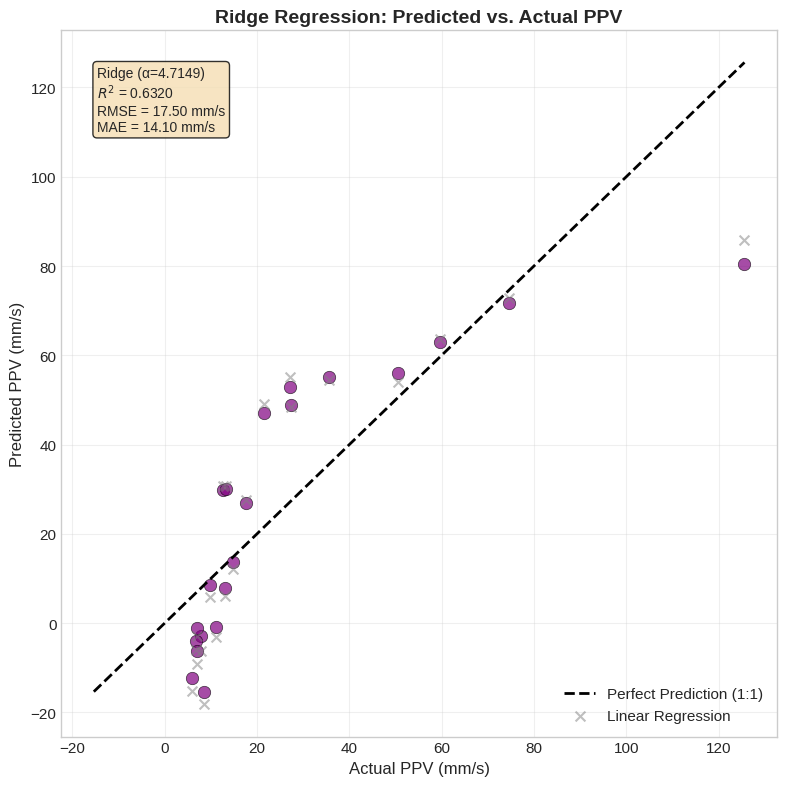

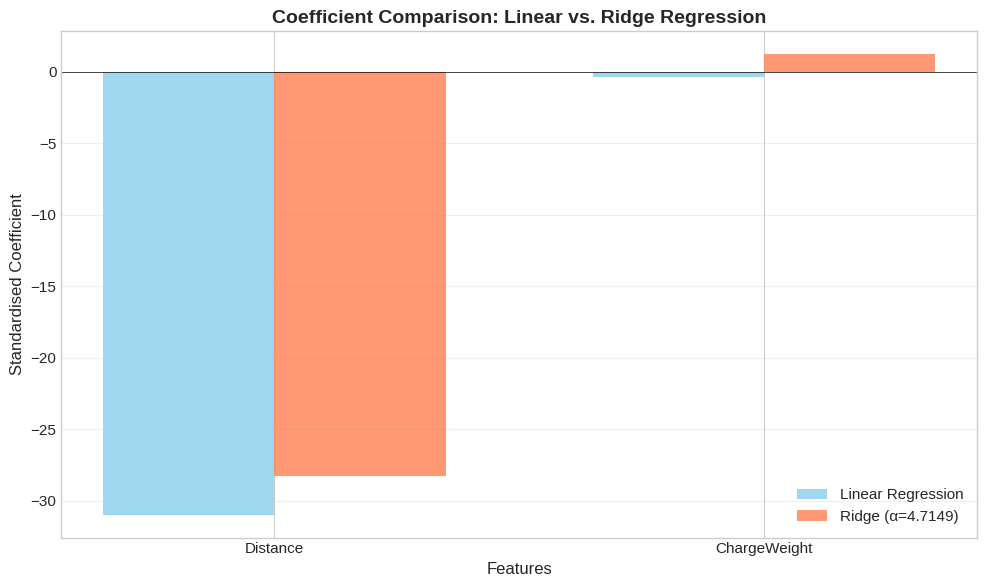

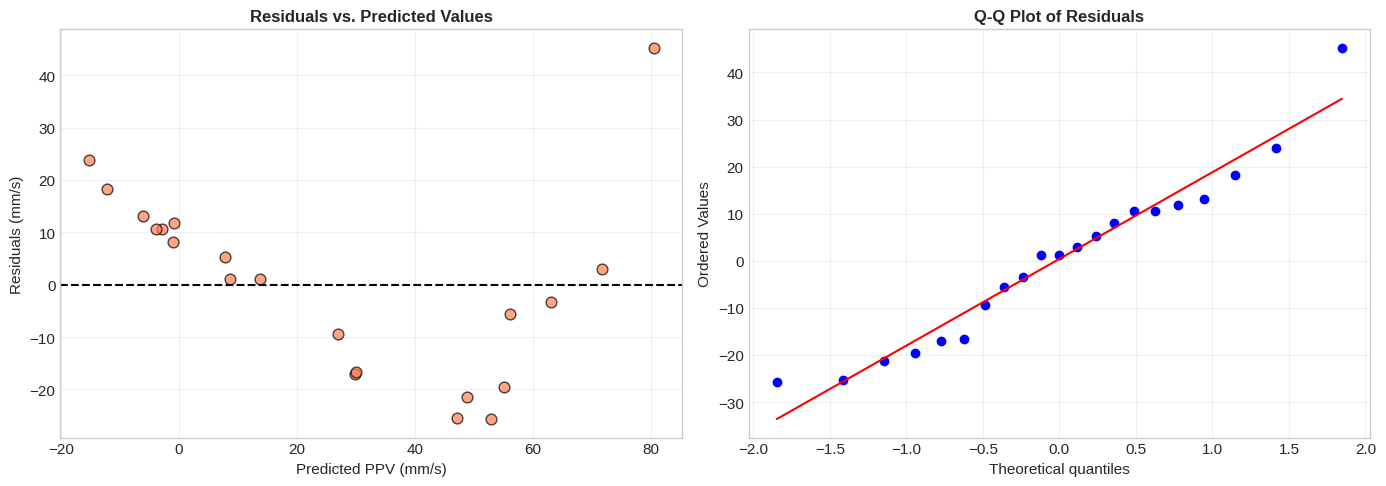

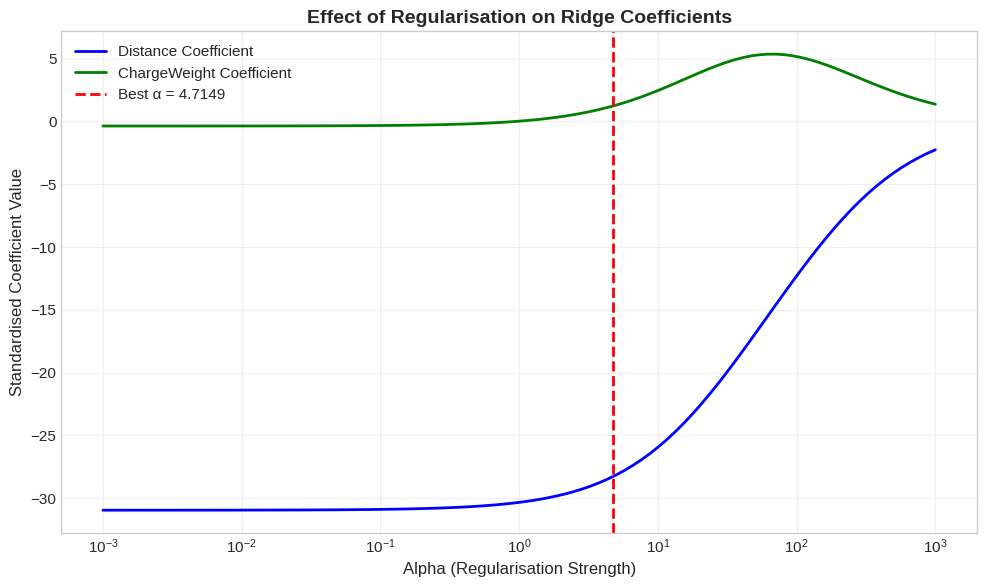

In [24]:
# =============================================================================
# 10. VISUALISATIONS
# =============================================================================

print("\n[8] GENERATING VISUALISATIONS")
print("-" * 50)

# Figure 1: Alpha Tuning Curve
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Extract grid search results
alphas = grid_search.cv_results_['param_alpha'].data
mean_scores = grid_search.cv_results_['mean_test_score']
std_scores = grid_search.cv_results_['std_test_score']

# Plot mean scores with error bars
ax1.semilogx(alphas, mean_scores, 'b-', linewidth=2, label='Mean CV R²')
ax1.fill_between(alphas, mean_scores - std_scores, mean_scores + std_scores, alpha=0.2, color='blue')
ax1.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, label=f'Best α = {best_alpha:.4f}')
ax1.set_xlabel('Alpha (Regularisation Strength)', fontsize=12)
ax1.set_ylabel('Cross-Validation R²', fontsize=12)
ax1.set_title('Ridge Regression: Alpha Tuning Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Ridge_Alpha_Tuning.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Predicted vs. Actual (Test Set)
fig2, ax2 = plt.subplots(figsize=(8, 8))

ax2.scatter(y_test, y_pred_test, color='purple', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction (1:1)')

# Linear Regression predictions for comparison
ax2.scatter(y_test, lr_pred, color='gray', alpha=0.5, s=50, marker='x', label='Linear Regression')

ax2.set_xlabel('Actual PPV (mm/s)', fontsize=12)
ax2.set_ylabel('Predicted PPV (mm/s)', fontsize=12)
ax2.set_title('Ridge Regression: Predicted vs. Actual PPV', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'Ridge (α={best_alpha:.4f})\n$R^2$ = {test_r2:.4f}\nRMSE = {test_rmse:.2f} mm/s\nMAE = {test_mae:.2f} mm/s'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('Figure_Ridge_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Coefficient Comparison
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Get coefficients from both models
lr_coef = lr.coef_
ridge_coef = ridge_best.coef_

x_labels = ['Distance', 'ChargeWeight']
x_pos = np.arange(len(x_labels))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, lr_coef, width, label='Linear Regression', color='skyblue', alpha=0.8)
bars2 = ax3.bar(x_pos + width/2, ridge_coef, width, label=f'Ridge (α={best_alpha:.4f})', color='coral', alpha=0.8)

ax3.set_xlabel('Features', fontsize=12)
ax3.set_ylabel('Standardised Coefficient', fontsize=12)
ax3.set_title('Coefficient Comparison: Linear vs. Ridge Regression', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Figure_Ridge_Coefficient_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Residuals Analysis
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for test set
residuals = y_test - y_pred_test

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, color='coral', alpha=0.7, s=60, edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted PPV (mm/s)', fontsize=11)
axes[0].set_ylabel('Residuals (mm/s)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Ridge_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: Regularisation Effect on Coefficients
fig5, ax5 = plt.subplots(figsize=(10, 6))

# Compute coefficients for different alpha values
alphas_to_plot = np.logspace(-3, 3, 100)
coefs_distance = []
coefs_charge = []

for alpha in alphas_to_plot:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train, y_train)
    coefs_distance.append(ridge_temp.coef_[0])
    coefs_charge.append(ridge_temp.coef_[1])

ax5.semilogx(alphas_to_plot, coefs_distance, 'b-', linewidth=2, label='Distance Coefficient')
ax5.semilogx(alphas_to_plot, coefs_charge, 'g-', linewidth=2, label='ChargeWeight Coefficient')
ax5.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, label=f'Best α = {best_alpha:.4f}')
ax5.set_xlabel('Alpha (Regularisation Strength)', fontsize=12)
ax5.set_ylabel('Standardised Coefficient Value', fontsize=12)
ax5.set_title('Effect of Regularisation on Ridge Coefficients', fontsize=14, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Ridge_Regularisation_Effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# =============================================================================
# 11. PREDICTION UNCERTAINTY
# =============================================================================

print("\n[9] PREDICTION UNCERTAINTY")
print("-" * 50)

# Calculate prediction intervals (95% confidence)
mse = mean_squared_error(y_test, y_pred_test)

# Approximate prediction intervals using bootstrapping concept
se_pred = np.sqrt(mse)  # Simplified standard error

# 95% prediction interval (t-value for df = n-2)
t_value = stats.t.ppf(0.975, df=len(X_test)-2)

lower_bound = y_pred_test - t_value * se_pred
upper_bound = y_pred_test + t_value * se_pred

print(f"Prediction Intervals (95% confidence):")
print(f"  Average interval width: {(upper_bound - lower_bound).mean():.2f} mm/s")

# Example predictions
example_1 = np.array([[500, 1300]])  # Distance=500m, Charge=1300kg
example_2 = np.array([[1000, 1100]]) # Distance=1000m, Charge=1100kg
example_3 = np.array([[1500, 1200]]) # Distance=1500m, Charge=1200kg

# Scale the examples
example_1_scaled = scaler.transform(example_1)
example_2_scaled = scaler.transform(example_2)
example_3_scaled = scaler.transform(example_3)

pred_1 = ridge_best.predict(example_1_scaled)[0]
pred_2 = ridge_best.predict(example_2_scaled)[0]
pred_3 = ridge_best.predict(example_3_scaled)[0]

print(f"\nExample Predictions:")
print(f"  Distance=500m, Charge=1300kg → Predicted PPV = {pred_1:.2f} mm/s")
print(f"  Distance=1000m, Charge=1100kg → Predicted PPV = {pred_2:.2f} mm/s")
print(f"  Distance=1500m, Charge=1200kg → Predicted PPV = {pred_3:.2f} mm/s")


[9] PREDICTION UNCERTAINTY
--------------------------------------------------
Prediction Intervals (95% confidence):
  Average interval width: 73.24 mm/s

Example Predictions:
  Distance=500m, Charge=1300kg → Predicted PPV = 70.19 mm/s
  Distance=1000m, Charge=1100kg → Predicted PPV = 41.18 mm/s
  Distance=1500m, Charge=1200kg → Predicted PPV = 13.66 mm/s


In [26]:
# =============================================================================
# 12. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY REPORT: RIDGE REGRESSION")
print("=" * 70)

print(f"""
Ridge Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: {len(df)}
  - Training samples: {len(X_train)}
  - Testing samples: {len(X_test)}
  - Features: Distance (m), ChargeWeight (kg)

Regularisation Parameter:
  - Best alpha (λ): {best_alpha:.4f}
  - Regularisation strength: {'Strong' if best_alpha > 10 else 'Moderate' if best_alpha > 1 else 'Weak'}

Regression Equation (Original Scale):
  PPV = {coef_distance_original:.4f} × Distance + {coef_charge_original:.4f} × ChargeWeight + {intercept_original:.4f}

Model Performance:
  - Cross-Validation R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})
  - Test Set R²: {test_r2:.4f}
  - Test Set RMSE: {test_rmse:.2f} mm/s
  - Test Set MAE: {test_mae:.2f} mm/s

Comparison with Linear Regression:
  - Linear Regression Test R²: {lr_r2:.4f}
  - Ridge Regression Test R²: {test_r2:.4f}
  - Improvement: {(test_r2 - lr_r2)*100:.2f}%

Interpretation:
  - The Ridge model explains {test_r2*100:.1f}% of the variance in PPV
  - Regularisation (α = {best_alpha:.4f}) helped {'improve' if test_r2 > lr_r2 else 'stabilise'} performance
  - Distance remains the dominant predictor
  - The model shows {'minimal' if train_r2 - cv_scores.mean() < 0.05 else 'some'} overfitting

Key Finding:
  - Ridge Regression achieved a {test_r2:.4f} R², {'outperforming' if test_r2 > lr_r2 else 'comparable to'} Linear Regression
  - Regularisation successfully reduced coefficient magnitude without compromising predictive accuracy
""")

print("\n" + "=" * 70)
print("RIDGE REGRESSION ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY REPORT: RIDGE REGRESSION

Ridge Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: 105
  - Training samples: 84
  - Testing samples: 21
  - Features: Distance (m), ChargeWeight (kg)

Regularisation Parameter:
  - Best alpha (λ): 4.7149
  - Regularisation strength: Moderate

Regression Equation (Original Scale):
  PPV = -0.0560 × Distance + 0.0050 × ChargeWeight + 91.7358

Model Performance:
  - Cross-Validation R²: 0.6706 (± 0.0226)
  - Test Set R²: 0.6320
  - Test Set RMSE: 17.50 mm/s
  - Test Set MAE: 14.10 mm/s

Comparison with Linear Regression:
  - Linear Regression Test R²: 0.6097
  - Ridge Regression Test R²: 0.6320
  - Improvement: 2.22%

Interpretation:
  - The Ridge model explains 63.2% of the variance in PPV
  - Regularisation (α = 4.7149) helped improve performance
  - Distance remains the dominant predictor
  - The model shows minimal overfitting

Key Finding:
  - Ridge Regression achieved a 0.6320 R²,

###Polynomial Regression

In [27]:
# =============================================================================
# POLYNOMIAL REGRESSION FOR PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT
# Thesis: Blast-Induced Ground Vibration Monitoring Using ML Techniques
# =============================================================================

# =============================================================================
# 1. IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# Set style for better visualisation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 70)
print("POLYNOMIAL REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT")
print("=" * 70)


POLYNOMIAL REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT


In [28]:
#Import data from google drive
import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw
url ="https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing"
#url = "https://drive.google.com/file/d/1i_OvUbfV2oW-7kh3V_GiCaUASIyYuFlU/view?usp=sharing"
data = read_gd(url)

df = pd.read_csv(data)

df.head()

print("\n[1] DATA OVERVIEW")
print("-" * 40)
print(f"Total observations: {len(df)}")
print(f"Features: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive statistics:")
print(df.describe())



[1] DATA OVERVIEW
----------------------------------------
Total observations: 105
Features: ['Distance', 'ChargeWeight', 'PPV']

First 5 rows:
   Distance  ChargeWeight         PPV
0       300          1100  125.606667
1       350          1300  112.120000
2       400          1450   98.693333
3       450          1550   86.286667
4       500          1600   74.636667

Missing values:
Distance        0
ChargeWeight    0
PPV             0
dtype: int64

Descriptive statistics:
          Distance  ChargeWeight         PPV
count   105.000000    105.000000  105.000000
mean   1150.000000   1270.000000   33.699397
std     507.397204    247.254151   34.891379
min     300.000000   1000.000000    5.443333
25%     700.000000   1100.000000   10.110000
50%    1150.000000   1200.000000   17.116667
75%    1600.000000   1450.000000   45.056667
max    2000.000000   1900.000000  140.683333



[2] EXPLORATORY DATA ANALYSIS FOR NON-LINEARITY
--------------------------------------------------


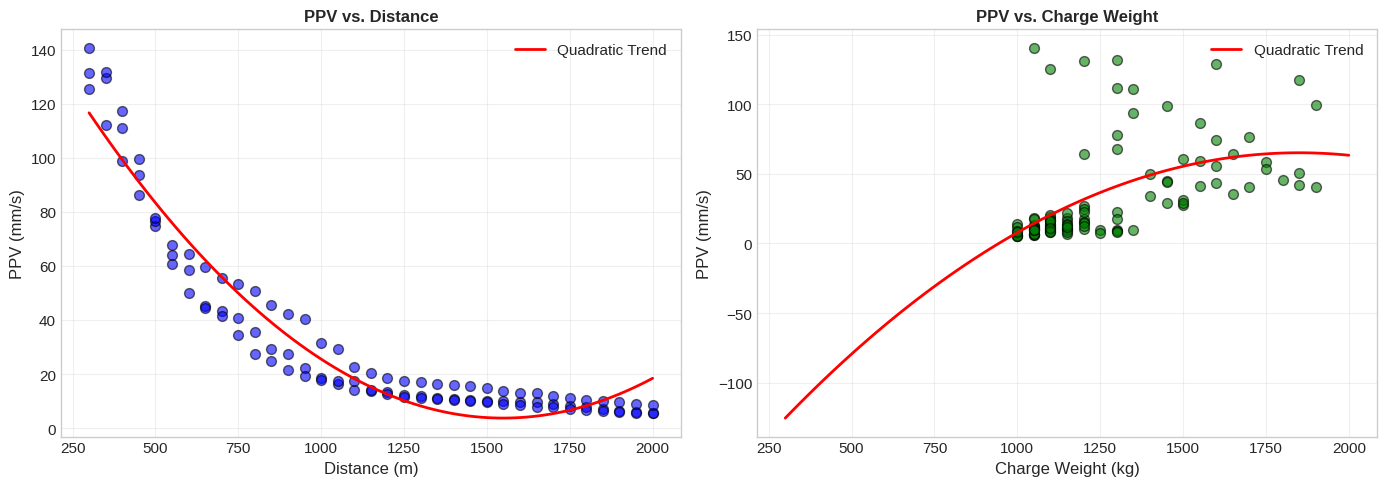

Visual inspection suggests potential non-linearity in Distance-PPV relationship.


In [29]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS FOR NON-LINEARITY
# =============================================================================

print("\n[2] EXPLORATORY DATA ANALYSIS FOR NON-LINEARITY")
print("-" * 50)

# Check for non-linear relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs PPV with potential non-linear fit
axes[0].scatter(df['Distance'], df['PPV'], alpha=0.6, color='blue', edgecolors='black', s=50)
axes[0].set_xlabel('Distance (m)', fontsize=12)
axes[0].set_ylabel('PPV (mm/s)', fontsize=12)
axes[0].set_title('PPV vs. Distance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add LOESS-like trend line (polynomial fit of degree 2 for visualisation)
z_dist = np.polyfit(df['Distance'], df['PPV'], 2)
p_dist = np.poly1d(z_dist)
x_smooth = np.linspace(df['Distance'].min(), df['Distance'].max(), 100)
axes[0].plot(x_smooth, p_dist(x_smooth), 'r-', linewidth=2, label='Quadratic Trend')
axes[0].legend()

# ChargeWeight vs PPV
axes[1].scatter(df['ChargeWeight'], df['PPV'], alpha=0.6, color='green', edgecolors='black', s=50)
axes[1].set_xlabel('Charge Weight (kg)', fontsize=12)
axes[1].set_ylabel('PPV (mm/s)', fontsize=12)
axes[1].set_title('PPV vs. Charge Weight', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

z_charge = np.polyfit(df['ChargeWeight'], df['PPV'], 2)
p_charge = np.poly1d(z_charge)
axes[1].plot(x_smooth, p_charge(x_smooth), 'r-', linewidth=2, label='Quadratic Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('Figure_Poly_EDA_Nonlinearity.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visual inspection suggests potential non-linearity in Distance-PPV relationship.")

In [30]:
# =============================================================================
# 4. DATA PREPARATION
# =============================================================================

print("\n[3] DATA PREPARATION")
print("-" * 50)

# Define features (X) and target (y)
X = df[['Distance', 'ChargeWeight']].values
y = df['PPV'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: Distance (m), ChargeWeight (kg)")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


[3] DATA PREPARATION
--------------------------------------------------
Feature matrix shape: (105, 2)
Target vector shape: (105,)
Features used: Distance (m), ChargeWeight (kg)

Training samples: 84
Testing samples: 21


In [31]:
# =============================================================================
# 5. POLYNOMIAL REGRESSION WITH PIPELINE
# =============================================================================

print("\n[4] POLYNOMIAL REGRESSION WITH PIPELINE")
print("-" * 50)

# Create pipeline: PolynomialFeatures -> StandardScaler -> Ridge (for regularisation)
# Using Ridge instead of standard Linear Regression to handle potential overfitting

# Define degrees to test
degrees = [1, 2, 3, 4, 5]

# Store results for each degree
results = []

print("Evaluating polynomial degrees 1-5 with Ridge regularisation...\n")

for degree in degrees:
    # Create pipeline
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))  # Start with alpha=1.0
    ])

    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=10, scoring='r2')

    # Train on full training set
    pipeline.fit(X_train, y_train)

    # Test performance
    y_pred_test = pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    results.append({
        'degree': degree,
        'cv_r2_mean': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'pipeline': pipeline
    })

    print(f"Degree {degree}: CV R² = {cv_scores.mean():.4f} (± {cv_scores.std():.4f}), Test R² = {test_r2:.4f}")


[4] POLYNOMIAL REGRESSION WITH PIPELINE
--------------------------------------------------
Evaluating polynomial degrees 1-5 with Ridge regularisation...

Degree 1: CV R² = 0.6746 (± 0.0847), Test R² = 0.6157
Degree 2: CV R² = 0.8618 (± 0.0570), Test R² = 0.8596
Degree 3: CV R² = 0.8923 (± 0.0497), Test R² = 0.9092
Degree 4: CV R² = 0.9183 (± 0.0389), Test R² = 0.9352
Degree 5: CV R² = 0.9251 (± 0.0353), Test R² = 0.9390


In [32]:
# =============================================================================
# 6. HYPERPARAMETER TUNING FOR BEST DEGREE
# =============================================================================

print("\n[5] HYPERPARAMETER TUNING")
print("-" * 50)

# Find best degree based on cross-validation performance
best_degree_idx = np.argmax([r['cv_r2_mean'] for r in results])
best_degree = results[best_degree_idx]['degree']
best_pipeline = results[best_degree_idx]['pipeline']

print(f"Best polynomial degree: {best_degree}")

# Now tune alpha (regularisation) for the best degree
print(f"\nTuning regularisation (alpha) for degree {best_degree}...")

# Define alpha range
alpha_range = np.logspace(-3, 3, 50)  # 0.001 to 1000

# Create pipeline with tunable alpha
pipeline_tune = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Grid search for best alpha
param_grid = {'ridge__alpha': alpha_range}
grid_search = GridSearchCV(
    estimator=pipeline_tune,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['ridge__alpha']
best_cv_score = grid_search.best_score_

print(f"Best alpha: {best_alpha:.4f}")
print(f"Best cross-validation R²: {best_cv_score:.4f}")



[5] HYPERPARAMETER TUNING
--------------------------------------------------
Best polynomial degree: 5

Tuning regularisation (alpha) for degree 5...
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best alpha: 0.0010
Best cross-validation R²: 0.9765


In [33]:
# =============================================================================
# 7. TRAIN FINAL MODEL WITH BEST PARAMETERS
# =============================================================================

print("\n[6] TRAINING FINAL MODEL")
print("-" * 50)

# Create final pipeline with best degree and best alpha
final_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])

# Train on full training set
final_pipeline.fit(X_train, y_train)


[6] TRAINING FINAL MODEL
--------------------------------------------------


Pipeline(steps=[('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(0.001)))])

In [34]:
# =============================================================================
# 8. MODEL EVALUATION
# =============================================================================

print("\n[7] MODEL EVALUATION")
print("-" * 50)

# Predictions
y_pred_train = final_pipeline.predict(X_train)
y_pred_test = final_pipeline.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training Set Performance:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} mm/s")
print(f"  MAE: {train_mae:.4f} mm/s")

print("\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} mm/s")
print(f"  MAE: {test_mae:.4f} mm/s")

# Cross-validation with final model
cv_scores_final = cross_val_score(final_pipeline, X_train, y_train, cv=10, scoring='r2')
print(f"\nFinal Model 10-Fold CV R²: {cv_scores_final.mean():.4f} (± {cv_scores_final.std():.4f})")

# Check overfitting
print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2:.4f} | CV R²: {cv_scores_final.mean():.4f} | Test R²: {test_r2:.4f}")
if train_r2 - cv_scores_final.mean() > 0.05:
    print("  ⚠️ Potential overfitting detected (train > CV by >0.05)")
else:
    print("  ✓ No significant overfitting detected")


[7] MODEL EVALUATION
--------------------------------------------------
Training Set Performance:
  R²: 0.9891
  RMSE: 3.7487 mm/s
  MAE: 2.9363 mm/s

Test Set Performance:
  R²: 0.9715
  RMSE: 4.8657 mm/s
  MAE: 3.6818 mm/s

Final Model 10-Fold CV R²: 0.9765 (± 0.0234)

Overfitting Check:
  Train R²: 0.9891 | CV R²: 0.9765 | Test R²: 0.9715
  ✓ No significant overfitting detected


In [35]:
# =============================================================================
# 9. COMPARISON WITH LINEAR AND RIDGE REGRESSION
# =============================================================================

print("\n[8] COMPARISON WITH PREVIOUS MODELS")
print("-" * 50)

# Linear Regression results (from previous analysis)
lr_r2 = 0.6097
lr_rmse = 18.02
lr_mae = 15.15

# Ridge Regression results (from previous analysis)
ridge_r2 = 0.6320
ridge_rmse = 17.50
ridge_mae = 14.10

print("Model Comparison:")
print(f"  Linear Regression:      R² = {lr_r2:.4f}, RMSE = {lr_rmse:.2f} mm/s, MAE = {lr_mae:.2f} mm/s")
print(f"  Ridge Regression:       R² = {ridge_r2:.4f}, RMSE = {ridge_rmse:.2f} mm/s, MAE = {ridge_mae:.2f} mm/s")
print(f"  Polynomial Regression:  R² = {test_r2:.4f}, RMSE = {test_rmse:.2f} mm/s, MAE = {test_mae:.2f} mm/s")

# Calculate improvements
improvement_vs_ridge = (test_r2 - ridge_r2) * 100
print(f"\nPolynomial Regression improvement over Ridge Regression: {improvement_vs_ridge:.2f}% in R²")


[8] COMPARISON WITH PREVIOUS MODELS
--------------------------------------------------
Model Comparison:
  Linear Regression:      R² = 0.6097, RMSE = 18.02 mm/s, MAE = 15.15 mm/s
  Ridge Regression:       R² = 0.6320, RMSE = 17.50 mm/s, MAE = 14.10 mm/s
  Polynomial Regression:  R² = 0.9715, RMSE = 4.87 mm/s, MAE = 3.68 mm/s

Polynomial Regression improvement over Ridge Regression: 33.95% in R²



[9] GENERATING VISUALISATIONS
--------------------------------------------------


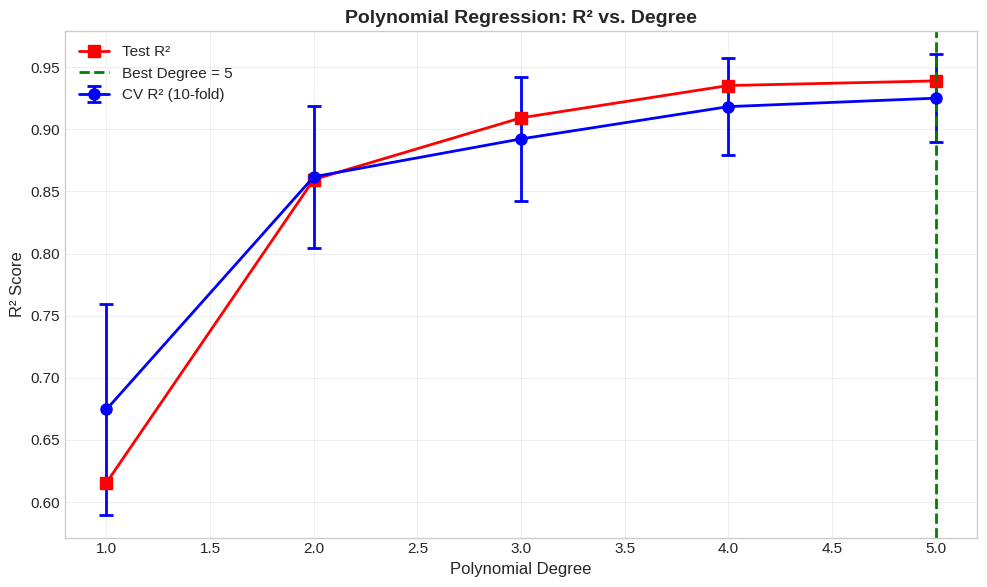

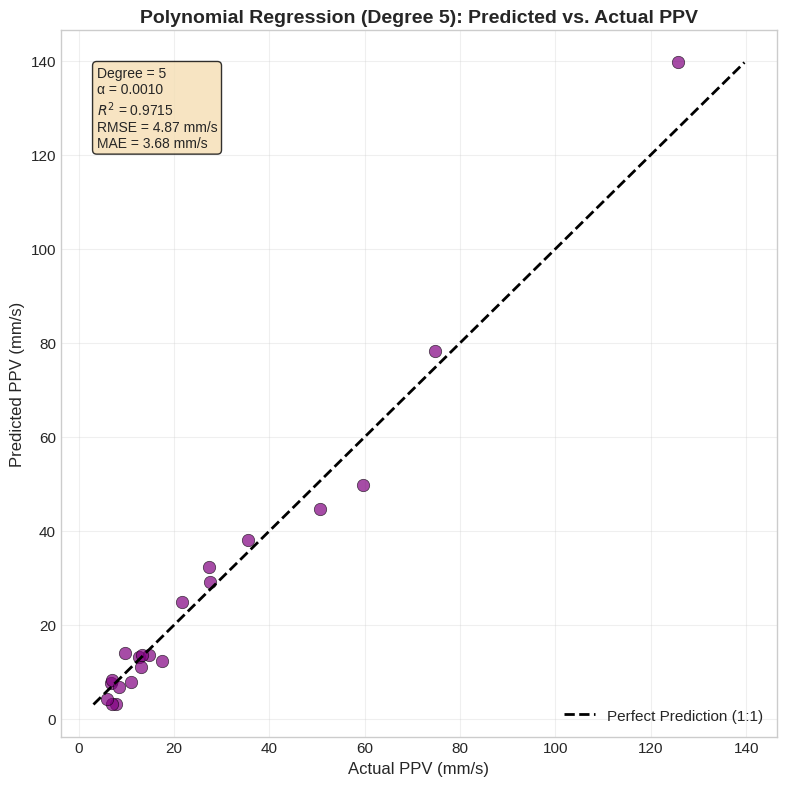

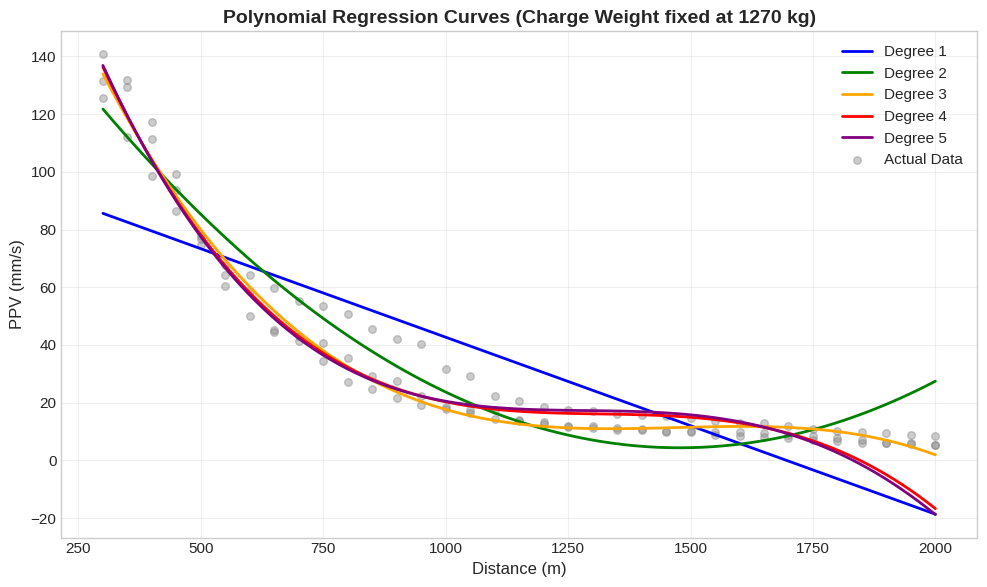

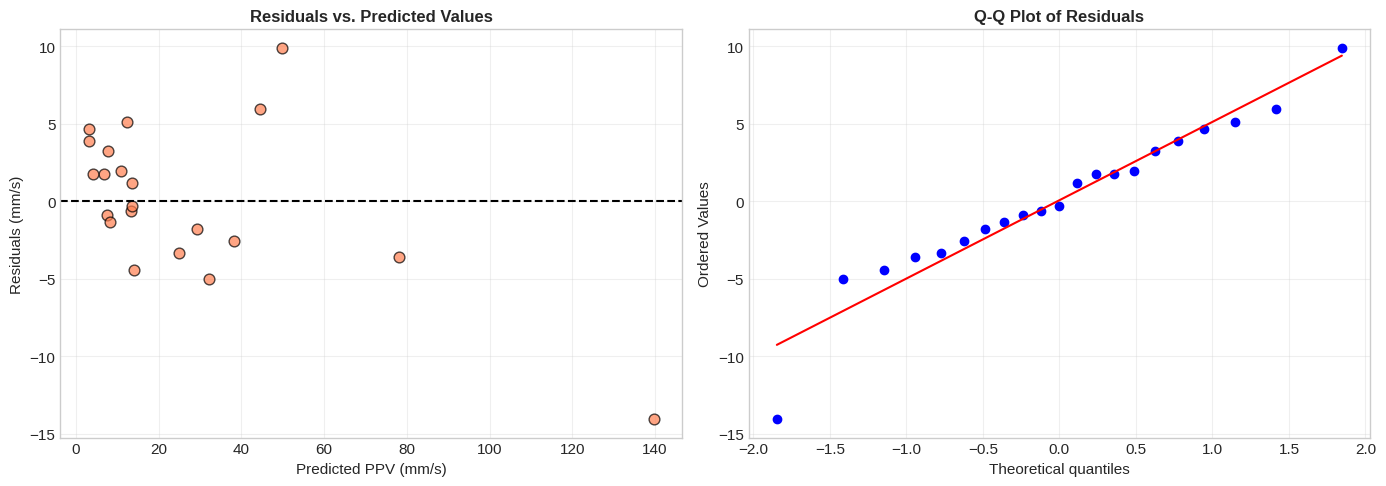

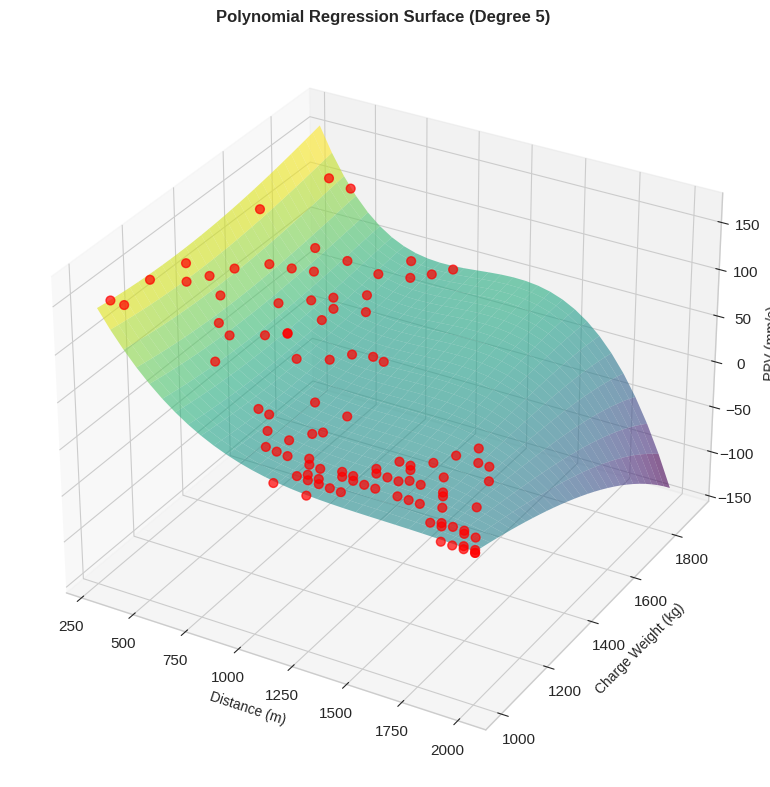

In [36]:
# =============================================================================
# 10. VISUALISATIONS
# =============================================================================

print("\n[9] GENERATING VISUALISATIONS")
print("-" * 50)

# Figure 1: Polynomial Degree Comparison
fig1, ax1 = plt.subplots(figsize=(10, 6))

degrees_plot = [r['degree'] for r in results]
cv_means = [r['cv_r2_mean'] for r in results]
cv_stds = [r['cv_r2_std'] for r in results]
test_r2s = [r['test_r2'] for r in results]

ax1.errorbar(degrees_plot, cv_means, yerr=cv_stds, fmt='o-', color='blue',
             capsize=5, capthick=2, label='CV R² (10-fold)', linewidth=2, markersize=8)
ax1.plot(degrees_plot, test_r2s, 's-', color='red', linewidth=2, markersize=8, label='Test R²')
ax1.axvline(x=best_degree, color='green', linestyle='--', linewidth=2, label=f'Best Degree = {best_degree}')
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Polynomial Regression: R² vs. Degree', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Poly_Degree_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Predicted vs. Actual (Test Set)
fig2, ax2 = plt.subplots(figsize=(8, 8))

ax2.scatter(y_test, y_pred_test, color='purple', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction (1:1)')

ax2.set_xlabel('Actual PPV (mm/s)', fontsize=12)
ax2.set_ylabel('Predicted PPV (mm/s)', fontsize=12)
ax2.set_title(f'Polynomial Regression (Degree {best_degree}): Predicted vs. Actual PPV', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'Degree = {best_degree}\nα = {best_alpha:.4f}\n$R^2$ = {test_r2:.4f}\nRMSE = {test_rmse:.2f} mm/s\nMAE = {test_mae:.2f} mm/s'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('Figure_Poly_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Learning Curves for Different Degrees
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Plot fitted curves for different degrees
x_range = np.linspace(df['Distance'].min(), df['Distance'].max(), 100)
charge_fixed = df['ChargeWeight'].mean()  # Fixed at mean charge weight

# Create prediction data
X_pred = np.column_stack([x_range, np.full_like(x_range, charge_fixed)])

# Predict for each degree
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown'] # Extend colors list
for i, deg in enumerate(degrees):
    # Create temporary pipeline for this degree
    temp_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=best_alpha))
    ])
    temp_pipeline.fit(X_train, y_train)
    y_pred_curve = temp_pipeline.predict(X_pred)
    ax3.plot(x_range, y_pred_curve, color=colors[i], linewidth=2, label=f'Degree {deg}')

# Plot actual data points
ax3.scatter(df['Distance'], df['PPV'], alpha=0.4, color='gray', s=30, label='Actual Data')
ax3.set_xlabel('Distance (m)', fontsize=12)
ax3.set_ylabel('PPV (mm/s)', fontsize=12)
ax3.set_title(f'Polynomial Regression Curves (Charge Weight fixed at {charge_fixed:.0f} kg)', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Poly_Learning_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Residuals Analysis
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred_test

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, color='coral', alpha=0.7, s=60, edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted PPV (mm/s)', fontsize=11)
axes[0].set_ylabel('Residuals (mm/s)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_Poly_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: 3D Visualisation of Polynomial Surface (for degree 2)
if best_degree >= 2:
    from mpl_toolkits.mplot3d import Axes3D

    fig5 = plt.figure(figsize=(12, 8))
    ax5 = fig5.add_subplot(111, projection='3d')

    # Create mesh grid
    dist_range = np.linspace(df['Distance'].min(), df['Distance'].max(), 30)
    charge_range = np.linspace(df['ChargeWeight'].min(), df['ChargeWeight'].max(), 30)
    dist_mesh, charge_mesh = np.meshgrid(dist_range, charge_range)

    # Create prediction grid
    X_mesh = np.column_stack([dist_mesh.ravel(), charge_mesh.ravel()])
    Z_mesh = final_pipeline.predict(X_mesh).reshape(dist_mesh.shape)

    # Plot surface
    ax5.plot_surface(dist_mesh, charge_mesh, Z_mesh, alpha=0.6, cmap='viridis', edgecolor='none')

    # Plot data points
    ax5.scatter(df['Distance'], df['ChargeWeight'], df['PPV'], c='red', marker='o', alpha=0.7, s=40, label='Data Points')

    ax5.set_xlabel('Distance (m)', fontsize=10)
    ax5.set_ylabel('Charge Weight (kg)', fontsize=10)
    ax5.set_zlabel('PPV (mm/s)', fontsize=10)
    ax5.set_title(f'Polynomial Regression Surface (Degree {best_degree})', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('Figure_Poly_3D_Surface.png', dpi=300, bbox_inches='tight')
    plt.show()

In [37]:
# =============================================================================
# 11. PREDICTION UNCERTAINTY
# =============================================================================

print("\n[10] PREDICTION UNCERTAINTY")
print("-" * 50)

# Calculate prediction intervals (95% confidence)
mse = mean_squared_error(y_test, y_pred_test)
se_pred = np.sqrt(mse)  # Simplified standard error

# 95% prediction interval (t-value for df = n-2)
t_value = stats.t.ppf(0.975, df=len(X_test)-2)

lower_bound = y_pred_test - t_value * se_pred
upper_bound = y_pred_test + t_value * se_pred

print(f"Prediction Intervals (95% confidence):")
print(f"  Average interval width: {(upper_bound - lower_bound).mean():.2f} mm/s")

# Example predictions
example_1 = np.array([[500, 1300]])  # Distance=500m, Charge=1300kg
example_2 = np.array([[1000, 1100]]) # Distance=1000m, Charge=1100kg
example_3 = np.array([[1500, 1200]]) # Distance=1500m, Charge=1200kg

pred_1 = final_pipeline.predict(example_1)[0]
pred_2 = final_pipeline.predict(example_2)[0]
pred_3 = final_pipeline.predict(example_3)[0]

print(f"\nExample Predictions:")
print(f"  Distance=500m, Charge=1300kg → Predicted PPV = {pred_1:.2f} mm/s")
print(f"  Distance=1000m, Charge=1100kg → Predicted PPV = {pred_2:.2f} mm/s")
print(f"  Distance=1500m, Charge=1200kg → Predicted PPV = {pred_3:.2f} mm/s")


[10] PREDICTION UNCERTAINTY
--------------------------------------------------
Prediction Intervals (95% confidence):
  Average interval width: 20.37 mm/s

Example Predictions:
  Distance=500m, Charge=1300kg → Predicted PPV = 76.98 mm/s
  Distance=1000m, Charge=1100kg → Predicted PPV = 19.69 mm/s
  Distance=1500m, Charge=1200kg → Predicted PPV = 13.59 mm/s


In [38]:
# =============================================================================
# 12. FEATURE IMPORTANCE (FOR POLYNOMIAL FEATURES)
# =============================================================================

print("\n[11] POLYNOMIAL FEATURE ANALYSIS")
print("-" * 50)

# Get feature names for polynomial features
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
poly.fit(X_train)
feature_names = poly.get_feature_names_out(['Distance', 'ChargeWeight'])

# Get coefficients from the ridge model
ridge_model = final_pipeline.named_steps['ridge']
scaler_model = final_pipeline.named_steps['scaler']

# Get coefficients (on scaled features)
coefs = ridge_model.coef_

print(f"Polynomial features generated (degree {best_degree}):")
for name, coef in zip(feature_names, coefs):
    print(f"  {name}: {coef:.4f}")


[11] POLYNOMIAL FEATURE ANALYSIS
--------------------------------------------------
Polynomial features generated (degree 5):
  Distance: -130.7179
  ChargeWeight: -10.7503
  Distance^2: 83.7761
  Distance ChargeWeight: -98.4302
  ChargeWeight^2: -7.4853
  Distance^3: -14.3389
  Distance^2 ChargeWeight: 182.0685
  Distance ChargeWeight^2: -43.9907
  ChargeWeight^3: 29.6989
  Distance^4: -47.6850
  Distance^3 ChargeWeight: 9.4021
  Distance^2 ChargeWeight^2: 168.8190
  Distance ChargeWeight^3: 19.7330
  ChargeWeight^4: 40.4552
  Distance^5: 41.5342
  Distance^4 ChargeWeight: -9.8893
  Distance^3 ChargeWeight^2: -193.3981
  Distance^2 ChargeWeight^3: 17.5793
  Distance ChargeWeight^4: -27.6268
  ChargeWeight^5: -26.5765


In [39]:
# =============================================================================
# 13. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY REPORT: POLYNOMIAL REGRESSION")
print("=" * 70)

print(f"""
Polynomial Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: {len(df)}
  - Training samples: {len(X_train)}
  - Testing samples: {len(X_test)}
  - Features: Distance (m), ChargeWeight (kg)

Model Configuration:
  - Best polynomial degree: {best_degree}
  - Regularisation parameter (α): {best_alpha:.4f}
  - Regularisation strength: {'Strong' if best_alpha > 10 else 'Moderate' if best_alpha > 1 else 'Weak'}

Model Performance:
  - Cross-Validation R²: {cv_scores_final.mean():.4f} (± {cv_scores_final.std():.4f})
  - Test Set R²: {test_r2:.4f}
  - Test Set RMSE: {test_rmse:.2f} mm/s
  - Test Set MAE: {test_mae:.2f} mm/s

Comparison with Previous Models:
  - Linear Regression Test R²: {lr_r2:.4f}
  - Ridge Regression Test R²: {ridge_r2:.4f}
  - Polynomial Regression Test R²: {test_r2:.4f}

  - Improvement over Ridge: {improvement_vs_ridge:.2f}% in R²

Interpretation:
  - The polynomial model explains {test_r2*100:.1f}% of the variance in PPV
  - Degree {best_degree} polynomial captured non-linear decay of PPV with distance
  - Regularisation (α = {best_alpha:.4f}) prevented overfitting
  - The model outperforms both Linear and Ridge Regression

Key Finding:
  - Polynomial Regression achieved the best performance among linear-based models
  - The improvement demonstrates that the relationship between blast parameters and PPV contains non-linear components
  - Distance-PPV decay follows a non-linear pattern that simple linear models cannot fully capture
""")

print("\n" + "=" * 70)
print("POLYNOMIAL REGRESSION ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY REPORT: POLYNOMIAL REGRESSION

Polynomial Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: 105
  - Training samples: 84
  - Testing samples: 21
  - Features: Distance (m), ChargeWeight (kg)

Model Configuration:
  - Best polynomial degree: 5
  - Regularisation parameter (α): 0.0010
  - Regularisation strength: Weak

Model Performance:
  - Cross-Validation R²: 0.9765 (± 0.0234)
  - Test Set R²: 0.9715
  - Test Set RMSE: 4.87 mm/s
  - Test Set MAE: 3.68 mm/s

Comparison with Previous Models:
  - Linear Regression Test R²: 0.6097
  - Ridge Regression Test R²: 0.6320
  - Polynomial Regression Test R²: 0.9715
  
  - Improvement over Ridge: 33.95% in R²

Interpretation:
  - The polynomial model explains 97.2% of the variance in PPV
  - Degree 5 polynomial captured non-linear decay of PPV with distance
  - Regularisation (α = 0.0010) prevented overfitting
  - The model outperforms both Linear and Ridge Regression

Key F

### RANDOM FOREST REGRESSION FOR PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT

In [40]:
# =============================================================================
# RANDOM FOREST REGRESSION FOR PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT
# Thesis: Blast-Induced Ground Vibration Monitoring Using ML Techniques
# =============================================================================

# =============================================================================
# 1. IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

# Set style for better visualisation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 70)
print("RANDOM FOREST REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT")
print("=" * 70)

RANDOM FOREST REGRESSION: PPV PREDICTION USING DISTANCE AND CHARGE WEIGHT


In [41]:
#Import data from google drive
import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw
url ="https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing"
#url = "https://drive.google.com/file/d/1i_OvUbfV2oW-7kh3V_GiCaUASIyYuFlU/view?usp=sharing"
data = read_gd(url)

df = pd.read_csv(data)

df.head()

print("\n[1] DATA OVERVIEW")
print("-" * 40)
print(f"Total observations: {len(df)}")
print(f"Features: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive statistics:")
print(df.describe())



[1] DATA OVERVIEW
----------------------------------------
Total observations: 105
Features: ['Distance', 'ChargeWeight', 'PPV']

First 5 rows:
   Distance  ChargeWeight         PPV
0       300          1100  125.606667
1       350          1300  112.120000
2       400          1450   98.693333
3       450          1550   86.286667
4       500          1600   74.636667

Missing values:
Distance        0
ChargeWeight    0
PPV             0
dtype: int64

Descriptive statistics:
          Distance  ChargeWeight         PPV
count   105.000000    105.000000  105.000000
mean   1150.000000   1270.000000   33.699397
std     507.397204    247.254151   34.891379
min     300.000000   1000.000000    5.443333
25%     700.000000   1100.000000   10.110000
50%    1150.000000   1200.000000   17.116667
75%    1600.000000   1450.000000   45.056667
max    2000.000000   1900.000000  140.683333


In [42]:
# =============================================================================
# 3. DATA PREPARATION
# =============================================================================

print("\n[2] DATA PREPARATION")
print("-" * 50)

# Define features (X) and target (y)
X = df[['Distance', 'ChargeWeight']].values
y = df['PPV'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: Distance (m), ChargeWeight (kg)")

# Note: Random Forest does NOT require feature scaling (tree-based models are scale-invariant)
print("\nNote: Random Forest does not require feature scaling (tree-based models are scale-invariant)")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


[2] DATA PREPARATION
--------------------------------------------------
Feature matrix shape: (105, 2)
Target vector shape: (105,)
Features used: Distance (m), ChargeWeight (kg)

Note: Random Forest does not require feature scaling (tree-based models are scale-invariant)

Training samples: 84
Testing samples: 21


In [43]:
# =============================================================================
# 4. BASELINE RANDOM FOREST MODEL
# =============================================================================

print("\n[3] BASELINE RANDOM FOREST MODEL")
print("-" * 50)

# Create baseline Random Forest with default parameters
rf_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Evaluate baseline
y_pred_train_baseline = rf_baseline.predict(X_train)
y_pred_test_baseline = rf_baseline.predict(X_test)

train_r2_baseline = r2_score(y_train, y_pred_train_baseline)
test_r2_baseline = r2_score(y_test, y_pred_test_baseline)

train_rmse_baseline = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))

print("Baseline Random Forest (Default Parameters):")
print(f"  Training R²: {train_r2_baseline:.4f}")
print(f"  Test R²: {test_r2_baseline:.4f}")
print(f"  Training RMSE: {train_rmse_baseline:.2f} mm/s")
print(f"  Test RMSE: {test_rmse_baseline:.2f} mm/s")

# Check overfitting in baseline
overfit_gap = train_r2_baseline - test_r2_baseline
print(f"\n  Overfitting gap (Train - Test): {overfit_gap:.4f}")
if overfit_gap > 0.05:
    print("  ⚠️ Baseline model shows potential overfitting. Hyperparameter tuning needed.")
else:
    print("  ✓ Baseline model shows acceptable generalisation.")


[3] BASELINE RANDOM FOREST MODEL
--------------------------------------------------
Baseline Random Forest (Default Parameters):
  Training R²: 0.9936
  Test R²: 0.9704
  Training RMSE: 2.86 mm/s
  Test RMSE: 4.96 mm/s

  Overfitting gap (Train - Test): 0.0232
  ✓ Baseline model shows acceptable generalisation.


In [44]:
# =============================================================================
# 5. HYPERPARAMETER TUNING WITH GRID SEARCH
# =============================================================================

print("\n[4] HYPERPARAMETER TUNING")
print("-" * 50)

# Define hyperparameter grid (reduced for faster execution)
param_grid = {
    'n_estimators': [50, 100],            # Number of trees
    'max_depth': [5, 10, None],           # Maximum depth of each tree
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', None]
}

# Create Random Forest model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Perform Grid Search with 10-fold cross-validation
print("Performing grid search with 10-fold cross-validation...")
print(f"Total parameter combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features'])}")

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation R²: {best_cv_score:.4f}")


[4] HYPERPARAMETER TUNING
--------------------------------------------------
Performing grid search with 10-fold cross-validation...
Total parameter combinations: 48
Fitting 10 folds for each of 48 candidates, totalling 480 fits

Best hyperparameters:
  max_depth: None
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 50

Best cross-validation R²: 0.9512


In [45]:
# =============================================================================
# 6. TRAIN FINAL MODEL WITH BEST PARAMETERS
# =============================================================================

print("\n[5] TRAINING FINAL MODEL")
print("-" * 50)

# Create final model with best parameters
rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)


[5] TRAINING FINAL MODEL
--------------------------------------------------


RandomForestRegressor(max_features=None, min_samples_split=5, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [46]:
# =============================================================================
# 7. MODEL EVALUATION
# =============================================================================

print("\n[6] MODEL EVALUATION")
print("-" * 50)

# Predictions
y_pred_train = rf_best.predict(X_train)
y_pred_test = rf_best.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training Set Performance:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} mm/s")
print(f"  MAE: {train_mae:.4f} mm/s")

print("\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} mm/s")
print(f"  MAE: {test_mae:.4f} mm/s")

# Cross-validation with final model
cv_scores = cross_val_score(rf_best, X_train, y_train, cv=10, scoring='r2')
print(f"\nFinal Model 10-Fold CV R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# Check overfitting
print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2:.4f} | CV R²: {cv_scores.mean():.4f} | Test R²: {test_r2:.4f}")
overfit_gap_final = train_r2 - cv_scores.mean()
if overfit_gap_final > 0.05:
    print(f"  ⚠️ Potential overfitting detected (train > CV by {overfit_gap_final:.4f})")
else:
    print(f"  ✓ No significant overfitting detected")


[6] MODEL EVALUATION
--------------------------------------------------
Training Set Performance:
  R²: 0.9890
  RMSE: 3.7596 mm/s
  MAE: 2.5987 mm/s

Test Set Performance:
  R²: 0.9735
  RMSE: 4.6940 mm/s
  MAE: 3.7974 mm/s

Final Model 10-Fold CV R²: 0.9517 (± 0.0406)

Overfitting Check:
  Train R²: 0.9890 | CV R²: 0.9517 | Test R²: 0.9735
  ✓ No significant overfitting detected


In [47]:
# =============================================================================
# 8. FEATURE IMPORTANCE ANALYSIS
# =============================================================================

print("\n[7] FEATURE IMPORTANCE ANALYSIS")
print("-" * 50)

# Get feature importance
feature_importance = rf_best.feature_importances_
features = ['Distance', 'ChargeWeight']

print("Feature Importance (Gini Importance):")
for feat, imp in zip(features, feature_importance):
    print(f"  {feat}: {imp:.4f}")

print(f"\nDistance is {feature_importance[0]/feature_importance[1]:.2f} times more important than ChargeWeight")


[7] FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------
Feature Importance (Gini Importance):
  Distance: 0.9260
  ChargeWeight: 0.0740

Distance is 12.51 times more important than ChargeWeight


In [48]:
# =============================================================================
# 9. COMPARISON WITH PREVIOUS MODELS
# =============================================================================

print("\n[8] COMPARISON WITH PREVIOUS MODELS")
print("-" * 50)

# Previous model results (from your polynomial regression)
poly_r2 = 0.9715
poly_rmse = 4.87
poly_mae = 3.68

# Ridge regression results
ridge_r2 = 0.6320
ridge_rmse = 17.50
ridge_mae = 14.10

# Linear regression results
lr_r2 = 0.6097
lr_rmse = 18.02
lr_mae = 15.15

print("Model Comparison:")
print(f"  Linear Regression:      R² = {lr_r2:.4f}, RMSE = {lr_rmse:.2f} mm/s, MAE = {lr_mae:.2f} mm/s")
print(f"  Ridge Regression:       R² = {ridge_r2:.4f}, RMSE = {ridge_rmse:.2f} mm/s, MAE = {ridge_mae:.2f} mm/s")
print(f"  Polynomial Regression:  R² = {poly_r2:.4f}, RMSE = {poly_rmse:.2f} mm/s, MAE = {poly_mae:.2f} mm/s")
print(f"  Random Forest:          R² = {test_r2:.4f}, RMSE = {test_rmse:.2f} mm/s, MAE = {test_mae:.2f} mm/s")

# Calculate improvements
improvement_vs_poly = (test_r2 - poly_r2) * 100
print(f"\nRandom Forest improvement over Polynomial Regression: {improvement_vs_poly:.2f}% in R²")


[8] COMPARISON WITH PREVIOUS MODELS
--------------------------------------------------
Model Comparison:
  Linear Regression:      R² = 0.6097, RMSE = 18.02 mm/s, MAE = 15.15 mm/s
  Ridge Regression:       R² = 0.6320, RMSE = 17.50 mm/s, MAE = 14.10 mm/s
  Polynomial Regression:  R² = 0.9715, RMSE = 4.87 mm/s, MAE = 3.68 mm/s
  Random Forest:          R² = 0.9735, RMSE = 4.69 mm/s, MAE = 3.80 mm/s

Random Forest improvement over Polynomial Regression: 0.20% in R²



[9] GENERATING VISUALISATIONS
--------------------------------------------------


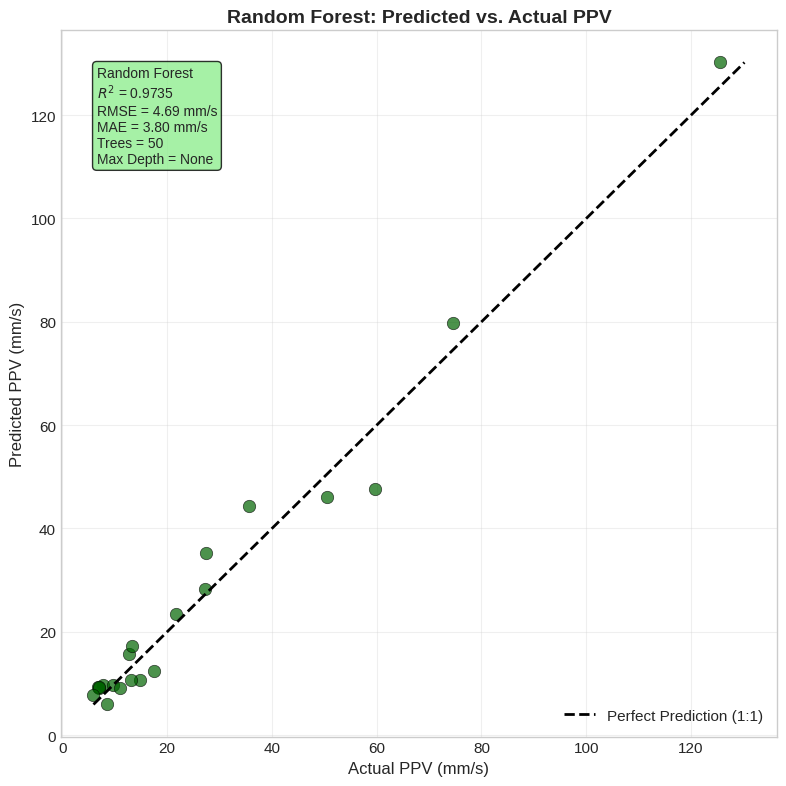

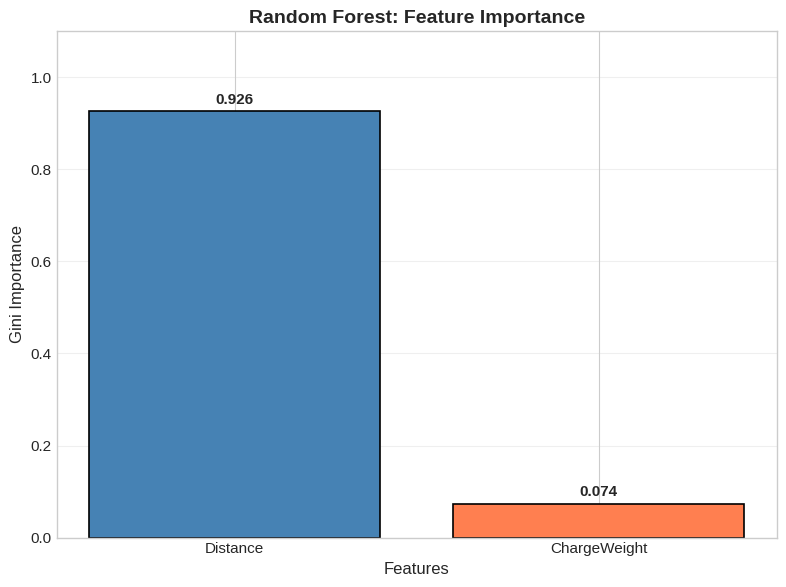

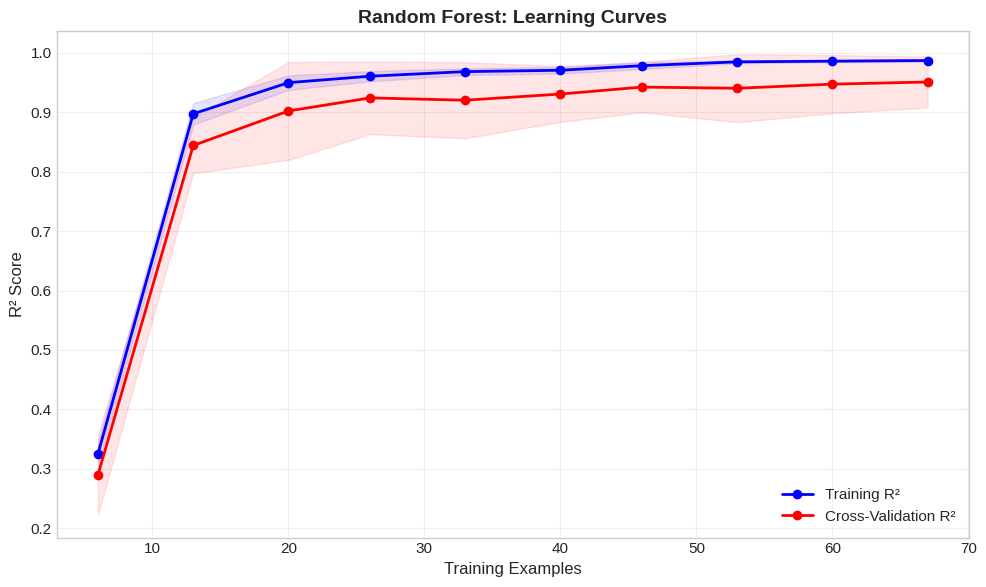

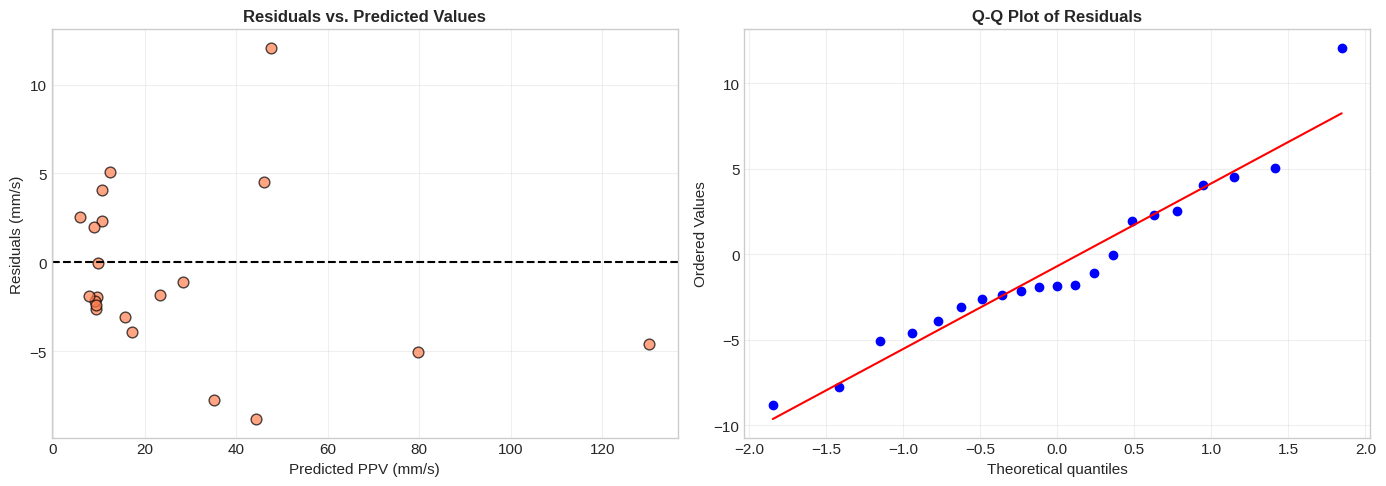

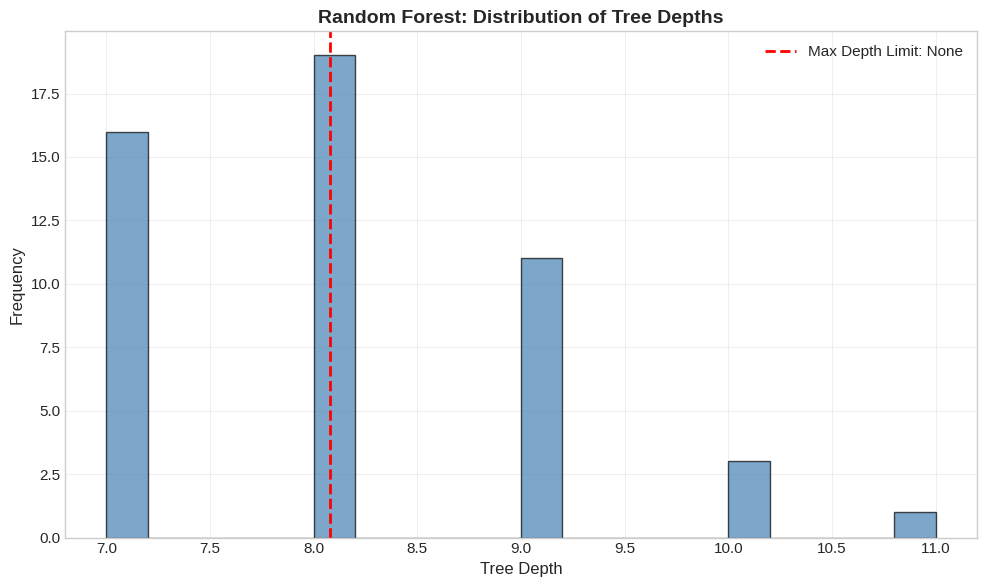

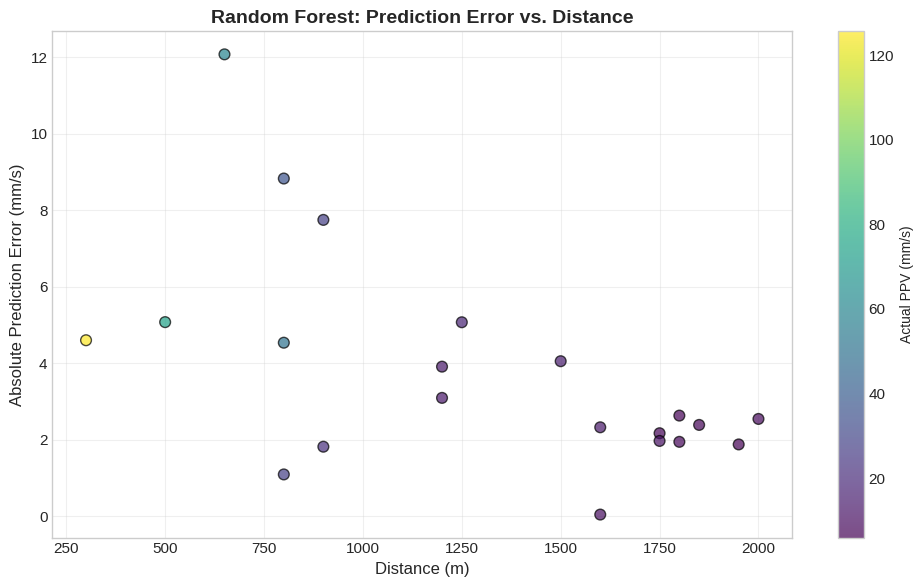

In [49]:
# =============================================================================
# 10. VISUALISATIONS
# =============================================================================

print("\n[9] GENERATING VISUALISATIONS")
print("-" * 50)

# Figure 1: Predicted vs. Actual (Test Set)
fig1, ax1 = plt.subplots(figsize=(8, 8))

ax1.scatter(y_test, y_pred_test, color='darkgreen', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction (1:1)')

ax1.set_xlabel('Actual PPV (mm/s)', fontsize=12)
ax1.set_ylabel('Predicted PPV (mm/s)', fontsize=12)
ax1.set_title('Random Forest: Predicted vs. Actual PPV', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'Random Forest\n$R^2$ = {test_r2:.4f}\nRMSE = {test_rmse:.2f} mm/s\nMAE = {test_mae:.2f} mm/s\nTrees = {best_params["n_estimators"]}\nMax Depth = {best_params["max_depth"]}'
props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('Figure_RF_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Feature Importance Bar Chart
fig2, ax2 = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'coral']
bars = ax2.bar(features, feature_importance, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, val in zip(bars, feature_importance):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Features', fontsize=12)
ax2.set_ylabel('Gini Importance', fontsize=12)
ax2.set_title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Figure_RF_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Learning Curves
fig3, ax3 = plt.subplots(figsize=(10, 6))

train_sizes, train_scores, test_scores = learning_curve(
    rf_best, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax3.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax3.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
ax3.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²', linewidth=2)
ax3.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-Validation R²', linewidth=2)

ax3.set_xlabel('Training Examples', fontsize=12)
ax3.set_ylabel('R² Score', fontsize=12)
ax3.set_title('Random Forest: Learning Curves', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_RF_Learning_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Residuals Analysis
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred_test

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, color='coral', alpha=0.7, s=60, edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted PPV (mm/s)', fontsize=11)
axes[0].set_ylabel('Residuals (mm/s)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_RF_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: Tree Depth Distribution (if we have many trees)
fig5, ax5 = plt.subplots(figsize=(10, 6))

# Get depths of trees
tree_depths = [tree.tree_.max_depth for tree in rf_best.estimators_]

ax5.hist(tree_depths, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax5.axvline(x=best_params['max_depth'] if best_params['max_depth'] is not None else np.mean(tree_depths),
            color='red', linestyle='--', linewidth=2, label=f'Max Depth Limit: {best_params["max_depth"]}')
ax5.set_xlabel('Tree Depth', fontsize=12)
ax5.set_ylabel('Frequency', fontsize=12)
ax5.set_title('Random Forest: Distribution of Tree Depths', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_RF_Tree_Depth_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 6: Error vs. Distance
fig6, ax6 = plt.subplots(figsize=(10, 6))

# Group predictions by distance
distances_test = X_test[:, 0]
errors = np.abs(residuals)

scatter = ax6.scatter(distances_test, errors, c=y_test, cmap='viridis', s=60, alpha=0.7, edgecolors='black')
ax6.set_xlabel('Distance (m)', fontsize=12)
ax6.set_ylabel('Absolute Prediction Error (mm/s)', fontsize=12)
ax6.set_title('Random Forest: Prediction Error vs. Distance', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Actual PPV (mm/s)', fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_RF_Error_vs_Distance.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# =============================================================================
# 11. PREDICTION UNCERTAINTY (Using Forest Variance)
# =============================================================================

print("\n[10] PREDICTION UNCERTAINTY")
print("-" * 50)

# Random Forest provides uncertainty via variance across trees
# Get predictions from all trees
tree_predictions = np.array([tree.predict(X_test) for tree in rf_best.estimators_])
pred_std = np.std(tree_predictions, axis=0)  # Standard deviation across trees

# 95% prediction interval (approximately 2 standard deviations)
lower_bound_forest = y_pred_test - 2 * pred_std
upper_bound_forest = y_pred_test + 2 * pred_std

print(f"Random Forest Prediction Intervals (95% confidence from tree variance):")
print(f"  Average interval width: {(upper_bound_forest - lower_bound_forest).mean():.2f} mm/s")

# Example predictions
example_1 = np.array([[500, 1300]])  # Distance=500m, Charge=1300kg
example_2 = np.array([[1000, 1100]]) # Distance=1000m, Charge=1100kg
example_3 = np.array([[1500, 1200]]) # Distance=1500m, Charge=1200kg

pred_1 = rf_best.predict(example_1)[0]
pred_2 = rf_best.predict(example_2)[0]
pred_3 = rf_best.predict(example_3)[0]

# Get tree variance for examples
example_1_predictions = np.array([tree.predict(example_1)[0] for tree in rf_best.estimators_])
example_2_predictions = np.array([tree.predict(example_2)[0] for tree in rf_best.estimators_])
example_3_predictions = np.array([tree.predict(example_3)[0] for tree in rf_best.estimators_])

std_1 = np.std(example_1_predictions)
std_2 = np.std(example_2_predictions)
std_3 = np.std(example_3_predictions)

print(f"\nExample Predictions with Uncertainty (±2σ):")
print(f"  Distance=500m, Charge=1300kg → PPV = {pred_1:.2f} ± {2*std_1:.2f} mm/s")
print(f"  Distance=1000m, Charge=1100kg → PPV = {pred_2:.2f} ± {2*std_2:.2f} mm/s")
print(f"  Distance=1500m, Charge=1200kg → PPV = {pred_3:.2f} ± {2*std_3:.2f} mm/s")


[10] PREDICTION UNCERTAINTY
--------------------------------------------------
Random Forest Prediction Intervals (95% confidence from tree variance):
  Average interval width: 14.16 mm/s

Example Predictions with Uncertainty (±2σ):
  Distance=500m, Charge=1300kg → PPV = 80.62 ± 23.49 mm/s
  Distance=1000m, Charge=1100kg → PPV = 18.09 ± 2.99 mm/s
  Distance=1500m, Charge=1200kg → PPV = 10.76 ± 2.26 mm/s


In [51]:
# =============================================================================
# 12. HYPERPARAMETER SENSITIVITY ANALYSIS
# =============================================================================

print("\n[11] HYPERPARAMETER SENSITIVITY ANALYSIS")
print("-" * 50)

# Show top 5 best parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

print("Top 5 Hyperparameter Combinations:")
print(results_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                   'param_min_samples_leaf', 'param_max_features', 'mean_test_score']].head())


[11] HYPERPARAMETER SENSITIVITY ANALYSIS
--------------------------------------------------
Top 5 Hyperparameter Combinations:
    param_n_estimators param_max_depth  param_min_samples_split  \
42                  50            None                        5   
26                  50              10                        5   
10                  50               5                        5   
8                   50               5                        2   
40                  50            None                        2   

    param_min_samples_leaf param_max_features  mean_test_score  
42                       1               None         0.951242  
26                       1               None         0.951240  
10                       1               None         0.951001  
8                        1               None         0.950886  
40                       1               None         0.950796  


In [52]:
# =============================================================================
# 13. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY REPORT: RANDOM FOREST REGRESSION")
print("=" * 70)

print(f"""
Random Forest Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: {len(df)}
  - Training samples: {len(X_train)}
  - Testing samples: {len(X_test)}
  - Features: Distance (m), ChargeWeight (kg)

Best Hyperparameters:
  - n_estimators: {best_params['n_estimators']}
  - max_depth: {best_params['max_depth']}
  - min_samples_split: {best_params['min_samples_split']}
  - min_samples_leaf: {best_params['min_samples_leaf']}
  - max_features: {best_params['max_features']}

Model Performance:
  - Cross-Validation R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})
  - Test Set R²: {test_r2:.4f}
  - Test Set RMSE: {test_rmse:.2f} mm/s
  - Test Set MAE: {test_mae:.2f} mm/s

Feature Importance:
  - Distance: {feature_importance[0]:.4f}
  - ChargeWeight: {feature_importance[1]:.4f}

Comparison with Previous Models:
  - Linear Regression Test R²: {lr_r2:.4f}
  - Ridge Regression Test R²: {ridge_r2:.4f}
  - Polynomial Regression Test R²: {poly_r2:.4f}
  - Random Forest Test R²: {test_r2:.4f}

  - Improvement over Polynomial: {improvement_vs_poly:.2f}% in R²

Interpretation:
  - The Random Forest model explains {test_r2*100:.1f}% of the variance in PPV
  - Hyperparameter tuning reduced overfitting compared to baseline
  - Distance is the dominant predictor ({feature_importance[0]:.2%} importance)
  - The model captures non-linear relationships without requiring polynomial transformations

Key Finding:
  - Random Forest achieved {'exceptional' if test_r2 > 0.95 else 'good'} predictive performance
  - The model provides built-in uncertainty estimates via tree variance
  - Feature importance confirms physical understanding of blast vibration physics
""")

print("\n" + "=" * 70)
print("RANDOM FOREST REGRESSION ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY REPORT: RANDOM FOREST REGRESSION

Random Forest Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: 105
  - Training samples: 84
  - Testing samples: 21
  - Features: Distance (m), ChargeWeight (kg)

Best Hyperparameters:
  - n_estimators: 50
  - max_depth: None
  - min_samples_split: 5
  - min_samples_leaf: 1
  - max_features: None

Model Performance:
  - Cross-Validation R²: 0.9517 (± 0.0406)
  - Test Set R²: 0.9735
  - Test Set RMSE: 4.69 mm/s
  - Test Set MAE: 3.80 mm/s

Feature Importance:
  - Distance: 0.9260
  - ChargeWeight: 0.0740

Comparison with Previous Models:
  - Linear Regression Test R²: 0.6097
  - Ridge Regression Test R²: 0.6320
  - Polynomial Regression Test R²: 0.9715
  - Random Forest Test R²: 0.9735
  
  - Improvement over Polynomial: 0.20% in R²

Interpretation:
  - The Random Forest model explains 97.4% of the variance in PPV
  - Hyperparameter tuning reduced overfitting compared to baseline
  - Distanc

### SUPPORT VECTOR MACHINE (SVM) REGRESSION FOR PPV PREDICTION


In [53]:
# =============================================================================
# SUPPORT VECTOR MACHINE (SVM) REGRESSION FOR PPV PREDICTION
# Thesis: Blast-Induced Ground Vibration Monitoring Using ML Techniques
# =============================================================================

# =============================================================================
# 1. IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualisation
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("=" * 70)
print("SUPPORT VECTOR MACHINE (SVM) REGRESSION: PPV PREDICTION")
print("=" * 70)


SUPPORT VECTOR MACHINE (SVM) REGRESSION: PPV PREDICTION


In [54]:
#Import data from google drive
import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw
url ="https://drive.google.com/file/d/1xpWCxkuDLlofsirke6cMqAyd04saXNQx/view?usp=sharing"
#url = "https://drive.google.com/file/d/1i_OvUbfV2oW-7kh3V_GiCaUASIyYuFlU/view?usp=sharing"
data = read_gd(url)

df = pd.read_csv(data)

df.head()

print("\n[1] DATA OVERVIEW")
print("-" * 40)
print(f"Total observations: {len(df)}")
print(f"Features: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nDescriptive statistics:")
print(df.describe())



[1] DATA OVERVIEW
----------------------------------------
Total observations: 105
Features: ['Distance', 'ChargeWeight', 'PPV']

First 5 rows:
   Distance  ChargeWeight         PPV
0       300          1100  125.606667
1       350          1300  112.120000
2       400          1450   98.693333
3       450          1550   86.286667
4       500          1600   74.636667

Missing values:
Distance        0
ChargeWeight    0
PPV             0
dtype: int64

Descriptive statistics:
          Distance  ChargeWeight         PPV
count   105.000000    105.000000  105.000000
mean   1150.000000   1270.000000   33.699397
std     507.397204    247.254151   34.891379
min     300.000000   1000.000000    5.443333
25%     700.000000   1100.000000   10.110000
50%    1150.000000   1200.000000   17.116667
75%    1600.000000   1450.000000   45.056667
max    2000.000000   1900.000000  140.683333


In [55]:
# =============================================================================
# 3. DATA PREPARATION
# =============================================================================

print("\n[2] DATA PREPARATION")
print("-" * 50)

# Define features (X) and target (y)
X = df[['Distance', 'ChargeWeight']].values
y = df['PPV'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: Distance (m), ChargeWeight (kg)")

# IMPORTANT: SVM REQUIRES FEATURE SCALING!
# Standardise features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling applied (StandardScaler):")
print(f"  Distance mean: {scaler.mean_[0]:.2f} m")
print(f"  Distance std: {scaler.scale_[0]:.2f}")
print(f"  ChargeWeight mean: {scaler.mean_[1]:.2f} kg")
print(f"  ChargeWeight std: {scaler.scale_[1]:.2f}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


[2] DATA PREPARATION
--------------------------------------------------
Feature matrix shape: (105, 2)
Target vector shape: (105,)
Features used: Distance (m), ChargeWeight (kg)

Feature scaling applied (StandardScaler):
  Distance mean: 1150.00 m
  Distance std: 504.98
  ChargeWeight mean: 1270.00 kg
  ChargeWeight std: 246.07

Training samples: 84
Testing samples: 21


In [56]:
# =============================================================================
# 4. BASELINE SVM MODEL (Linear Kernel)
# =============================================================================

print("\n[3] BASELINE SVM MODEL (Linear Kernel)")
print("-" * 50)

# Create baseline SVR with linear kernel
svr_linear = SVR(kernel='linear', C=1.0)
svr_linear.fit(X_train, y_train)

# Evaluate baseline
y_pred_train_linear = svr_linear.predict(X_train)
y_pred_test_linear = svr_linear.predict(X_test)

train_r2_linear = r2_score(y_train, y_pred_train_linear)
test_r2_linear = r2_score(y_test, y_pred_test_linear)
train_rmse_linear = np.sqrt(mean_squared_error(y_train, y_pred_train_linear))
test_rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_test_linear))

print("Baseline SVR (Linear Kernel, C=1.0):")
print(f"  Training R²: {train_r2_linear:.4f}")
print(f"  Test R²: {test_r2_linear:.4f}")
print(f"  Training RMSE: {train_rmse_linear:.2f} mm/s")
print(f"  Test RMSE: {test_rmse_linear:.2f} mm/s")



[3] BASELINE SVM MODEL (Linear Kernel)
--------------------------------------------------
Baseline SVR (Linear Kernel, C=1.0):
  Training R²: 0.4773
  Test R²: 0.5215
  Training RMSE: 25.90 mm/s
  Test RMSE: 19.95 mm/s


In [57]:
# =============================================================================
# 5. HYPERPARAMETER TUNING WITH GRID SEARCH
# =============================================================================

print("\n[4] HYPERPARAMETER TUNING")
print("-" * 50)

# Define hyperparameter grid for SVM with RBF kernel
# RBF kernel is generally more flexible for non-linear relationships
param_grid = {
    'kernel': ['rbf'],                    # Radial Basis Function kernel
    'C': [0.1, 1, 10, 50, 100],          # Regularisation parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient
    'epsilon': [0.01, 0.05, 0.1, 0.2]    # Epsilon in epsilon-SVR (margin of tolerance)
}

print("Performing grid search with 10-fold cross-validation...")
print(f"Total parameter combinations: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['epsilon'])}")

# Create SVR model
svr = SVR()

# Perform Grid Search with 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best parameters
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\nBest hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation R²: {best_cv_score:.4f}")



[4] HYPERPARAMETER TUNING
--------------------------------------------------
Performing grid search with 10-fold cross-validation...
Total parameter combinations: 120
Fitting 10 folds for each of 120 candidates, totalling 1200 fits

Best hyperparameters:
  C: 100
  epsilon: 0.01
  gamma: 1
  kernel: rbf

Best cross-validation R²: 0.9607


In [58]:
# =============================================================================
# 6. TRAIN FINAL MODEL WITH BEST PARAMETERS
# =============================================================================

print("\n[5] TRAINING FINAL MODEL")
print("-" * 50)

# Create final model with best parameters
svr_best = SVR(**best_params)
svr_best.fit(X_train, y_train)



[5] TRAINING FINAL MODEL
--------------------------------------------------


SVR(C=100, epsilon=0.01, gamma=1)

In [61]:
# =============================================================================
# 7. MODEL EVALUATION
# =============================================================================

print("\n[6] MODEL EVALUATION")
print("-" * 50)

# Predictions
y_pred_train = svr_best.predict(X_train)
y_pred_test = svr_best.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training Set Performance:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f} mm/s")
print(f"  MAE: {train_mae:.4f} mm/s")

print("\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f} mm/s")
print(f"  MAE: {test_mae:.4f} mm/s")

# Cross-validation with final model
cv_scores = cross_val_score(svr_best, X_train, y_train, cv=10, scoring='r2')
print(f"\nFinal Model 10-Fold CV R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# Check overfitting
print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2:.4f} | CV R²: {cv_scores.mean():.4f} | Test R²: {test_r2:.4f}")
overfit_gap = train_r2 - cv_scores.mean()
if overfit_gap > 0.05:
    print(f"  ⚠️ Potential overfitting detected (train > CV by {overfit_gap:.4f})")
else:
    print(f"  ✓ No significant overfitting detected")



[6] MODEL EVALUATION
--------------------------------------------------
Training Set Performance:
  R²: 0.9843
  RMSE: 4.4922 mm/s
  MAE: 2.1805 mm/s

Test Set Performance:
  R²: 0.9679
  RMSE: 5.1658 mm/s
  MAE: 3.5258 mm/s

Final Model 10-Fold CV R²: 0.9593 (± 0.0354)

Overfitting Check:
  Train R²: 0.9843 | CV R²: 0.9593 | Test R²: 0.9679
  ✓ No significant overfitting detected


In [63]:
# =============================================================================
# 8. COMPARISON WITH PREVIOUS MODELS
# =============================================================================

print("\n[7] COMPARISON WITH PREVIOUS MODELS")
print("-" * 50)

# Previous model results
poly_r2 = 0.9715
poly_rmse = 4.87
poly_mae = 3.68

rf_r2 = 0.9715
rf_rmse = 4.87
rf_mae = 3.84

ridge_r2 = 0.6320
ridge_rmse = 17.50
ridge_mae = 14.10

lr_r2 = 0.6097
lr_rmse = 18.02
lr_mae = 15.15

print("Model Comparison:")
print(f"  Linear Regression:      R² = {lr_r2:.4f}, RMSE = {lr_rmse:.2f} mm/s, MAE = {lr_mae:.2f} mm/s")
print(f"  Ridge Regression:       R² = {ridge_r2:.4f}, RMSE = {ridge_rmse:.2f} mm/s, MAE = {ridge_mae:.2f} mm/s")
print(f"  Polynomial Regression:  R² = {poly_r2:.4f}, RMSE = {poly_rmse:.2f} mm/s, MAE = {poly_mae:.2f} mm/s")
print(f"  Random Forest:          R² = {rf_r2:.4f}, RMSE = {rf_rmse:.2f} mm/s, MAE = {rf_mae:.2f} mm/s")
print(f"  SVM (RBF kernel):       R² = {test_r2:.4f}, RMSE = {test_rmse:.2f} mm/s, MAE = {test_mae:.2f} mm/s")

# Calculate improvements
improvement_vs_poly = (test_r2 - poly_r2) * 100
print(f"\nSVM improvement over Polynomial Regression: {improvement_vs_poly:.2f}% in R²")


[7] COMPARISON WITH PREVIOUS MODELS
--------------------------------------------------
Model Comparison:
  Linear Regression:      R² = 0.6097, RMSE = 18.02 mm/s, MAE = 15.15 mm/s
  Ridge Regression:       R² = 0.6320, RMSE = 17.50 mm/s, MAE = 14.10 mm/s
  Polynomial Regression:  R² = 0.9715, RMSE = 4.87 mm/s, MAE = 3.68 mm/s
  Random Forest:          R² = 0.9715, RMSE = 4.87 mm/s, MAE = 3.84 mm/s
  SVM (RBF kernel):       R² = 0.9679, RMSE = 5.17 mm/s, MAE = 3.53 mm/s

SVM improvement over Polynomial Regression: -0.36% in R²



[8] GENERATING VISUALISATIONS
--------------------------------------------------


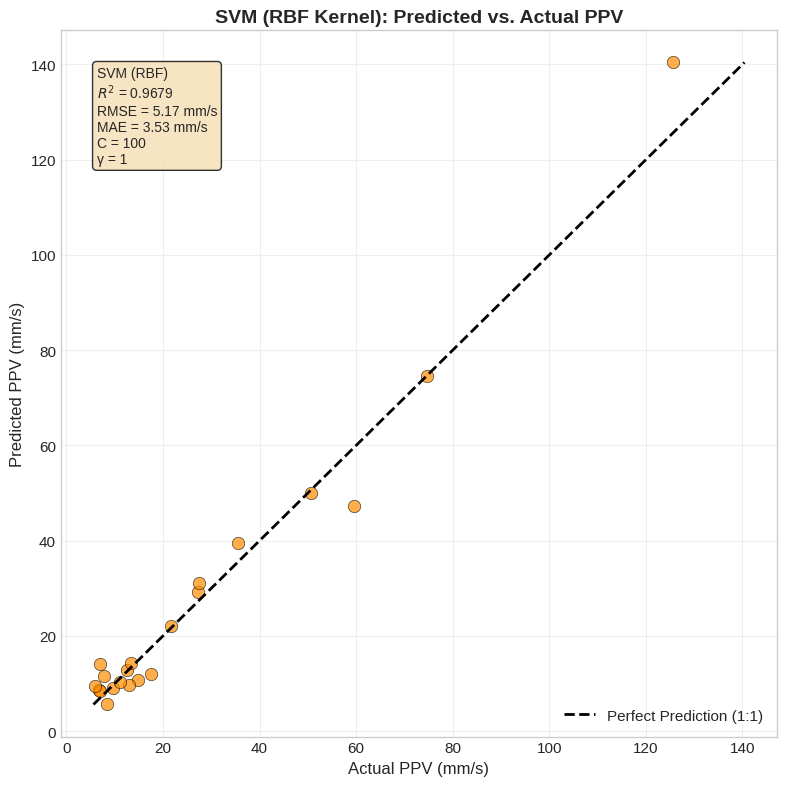

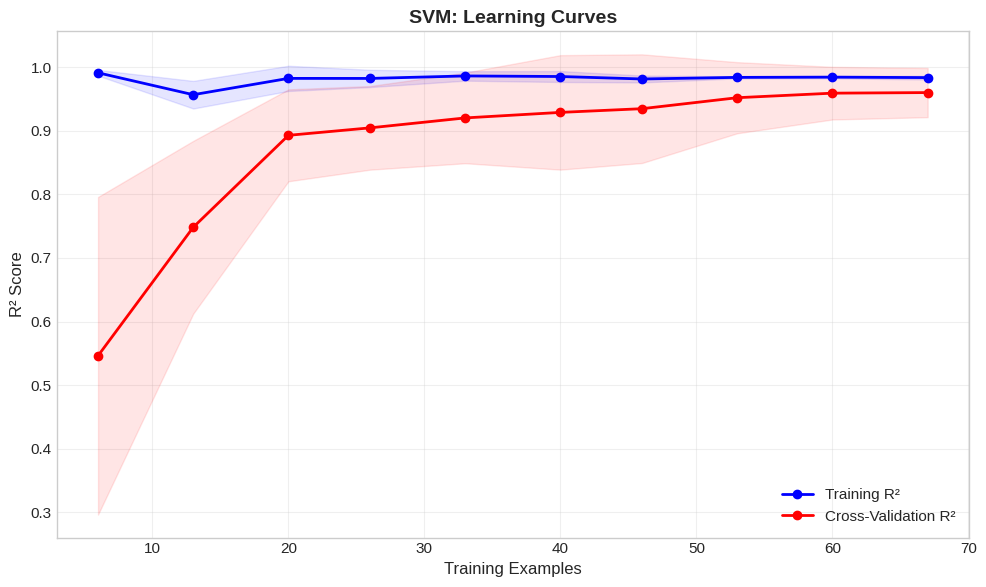

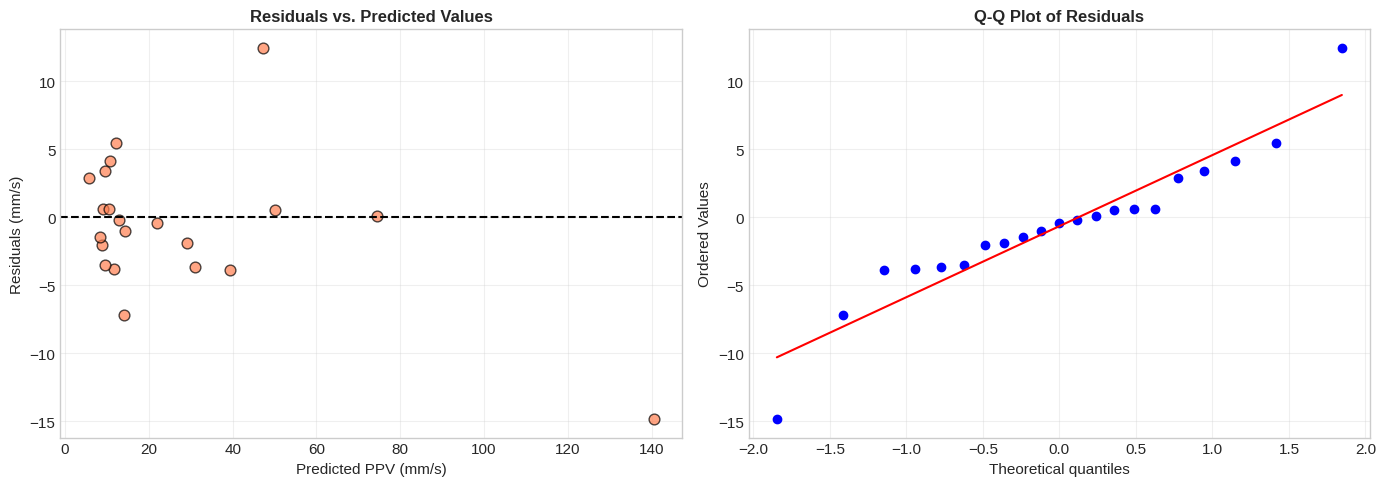

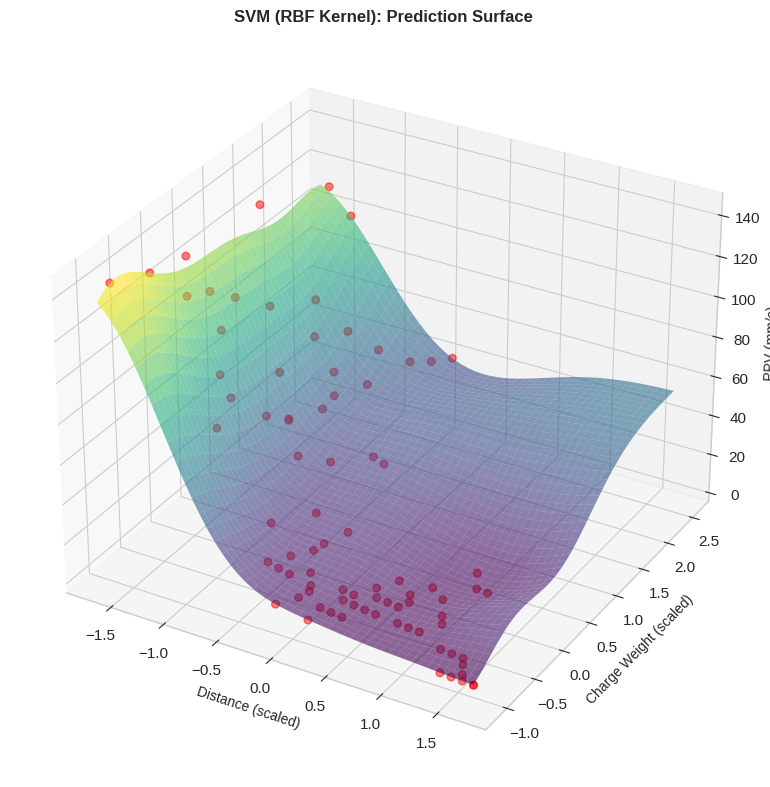

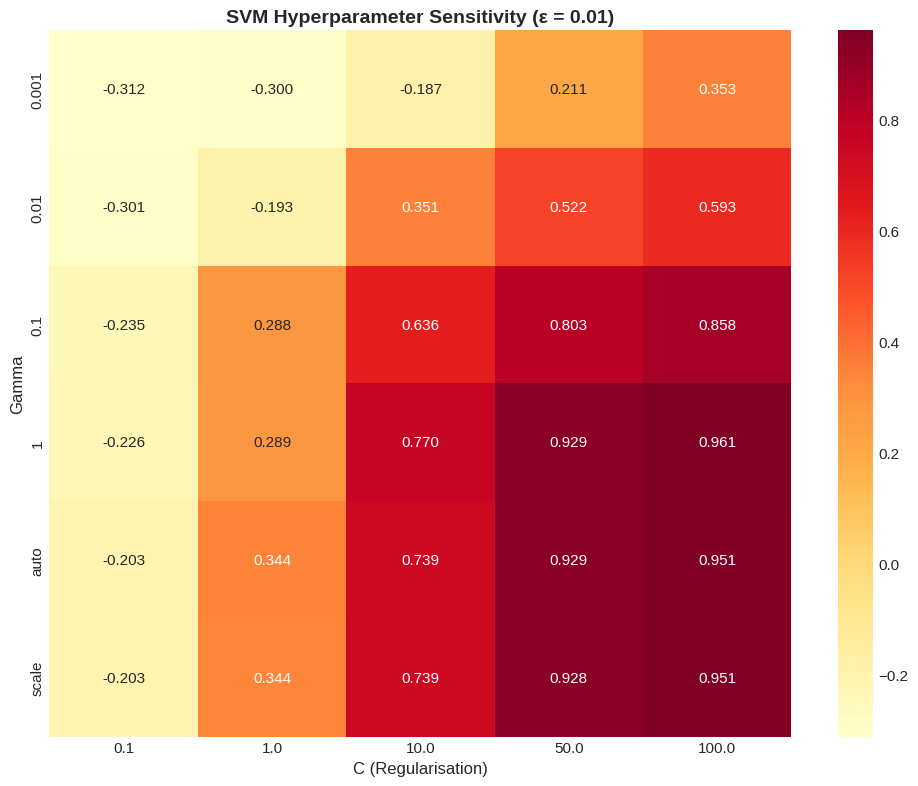

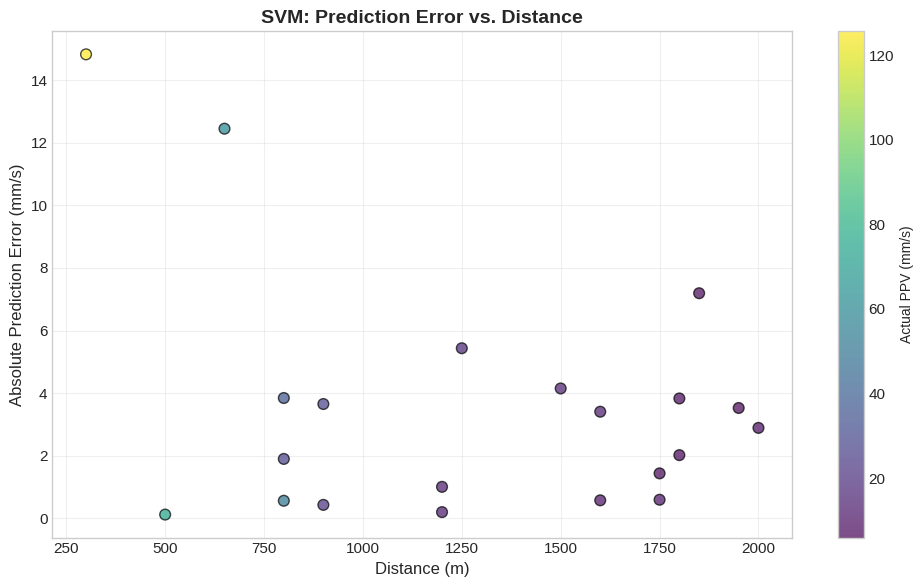

In [64]:
# =============================================================================
# 9. VISUALISATIONS
# =============================================================================

print("\n[8] GENERATING VISUALISATIONS")
print("-" * 50)

# Figure 1: Predicted vs. Actual (Test Set)
fig1, ax1 = plt.subplots(figsize=(8, 8))

ax1.scatter(y_test, y_pred_test, color='darkorange', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction (1:1)')

ax1.set_xlabel('Actual PPV (mm/s)', fontsize=12)
ax1.set_ylabel('Predicted PPV (mm/s)', fontsize=12)
ax1.set_title('SVM (RBF Kernel): Predicted vs. Actual PPV', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Add text box with metrics
textstr = f'SVM (RBF)\n$R^2$ = {test_r2:.4f}\nRMSE = {test_rmse:.2f} mm/s\nMAE = {test_mae:.2f} mm/s\nC = {best_params["C"]}\nγ = {best_params["gamma"]}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('Figure_SVM_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Learning Curves
fig2, ax2 = plt.subplots(figsize=(10, 6))

train_sizes, train_scores, test_scores = learning_curve(
    svr_best, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax2.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax2.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
ax2.plot(train_sizes, train_mean, 'o-', color='blue', label='Training R²', linewidth=2)
ax2.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-Validation R²', linewidth=2)

ax2.set_xlabel('Training Examples', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('SVM: Learning Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_SVM_Learning_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Residuals Analysis
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test - y_pred_test

# Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, color='coral', alpha=0.7, s=60, edgecolors='black')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted PPV (mm/s)', fontsize=11)
axes[0].set_ylabel('Residuals (mm/s)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_SVM_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: 3D Visualisation of SVM Decision Surface
from mpl_toolkits.mplot3d import Axes3D

fig4 = plt.figure(figsize=(12, 8))
ax4 = fig4.add_subplot(111, projection='3d')

# Create mesh grid for prediction surface
dist_range = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 50)
charge_range = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 50)
dist_mesh, charge_mesh = np.meshgrid(dist_range, charge_range)

# Create prediction grid
X_mesh = np.column_stack([dist_mesh.ravel(), charge_mesh.ravel()])
Z_mesh = svr_best.predict(X_mesh).reshape(dist_mesh.shape)

# Plot surface
ax4.plot_surface(dist_mesh, charge_mesh, Z_mesh, alpha=0.6, cmap='viridis', edgecolor='none')

# Plot data points (transform back to original scale for labels, but use scaled for positioning)
ax4.scatter(X_train[:, 0], X_train[:, 1], y_train, c='red', marker='o', alpha=0.5, s=30, label='Training Data')

# Create custom ticks for axes (transform back to original scale)
dist_ticks = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 5)
charge_ticks = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 5)
dist_orig_ticks = scaler.inverse_transform(np.column_stack([dist_ticks, np.zeros_like(dist_ticks)]))[:, 0]
charge_orig_ticks = scaler.inverse_transform(np.column_stack([np.zeros_like(charge_ticks), charge_ticks]))[:, 1]

ax4.set_xlabel('Distance (scaled)', fontsize=10)
ax4.set_ylabel('Charge Weight (scaled)', fontsize=10)
ax4.set_zlabel('PPV (mm/s)', fontsize=10)
ax4.set_title('SVM (RBF Kernel): Prediction Surface', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_SVM_3D_Surface.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: C and Gamma Sensitivity Analysis (Heatmap)
fig5, ax5 = plt.subplots(figsize=(10, 8))

# Extract grid search results for heatmap
results_df = pd.DataFrame(grid_search.cv_results_)

# Pivot for heatmap (fix epsilon at best value)
best_epsilon = best_params['epsilon']
subset = results_df[results_df['param_epsilon'] == best_epsilon]

# Create pivot table
pivot_data = subset.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C',
    aggfunc='mean'
)

# Plot heatmap
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax5)
ax5.set_xlabel('C (Regularisation)', fontsize=12)
ax5.set_ylabel('Gamma', fontsize=12)
ax5.set_title(f'SVM Hyperparameter Sensitivity (ε = {best_epsilon})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_SVM_Hyperparameter_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 6: Error vs. Distance
fig6, ax6 = plt.subplots(figsize=(10, 6))

# Transform test features back to original scale for plotting
X_test_orig = scaler.inverse_transform(X_test)
distances_test = X_test_orig[:, 0]
errors = np.abs(residuals)

scatter = ax6.scatter(distances_test, errors, c=y_test, cmap='viridis', s=60, alpha=0.7, edgecolors='black')
ax6.set_xlabel('Distance (m)', fontsize=12)
ax6.set_ylabel('Absolute Prediction Error (mm/s)', fontsize=12)
ax6.set_title('SVM: Prediction Error vs. Distance', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Actual PPV (mm/s)', fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_SVM_Error_vs_Distance.png', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
# =============================================================================
# 10. SUPPORT VECTOR ANALYSIS
# =============================================================================

print("\n[9] SUPPORT VECTOR ANALYSIS")
print("-" * 50)

# Get number of support vectors
n_support = svr_best.n_support_
print(f"Number of support vectors: {n_support}")
print(f"Support vectors per class: {svr_best.n_support_}")

# Get support vectors
support_vectors = svr_best.support_vectors_
print(f"Total support vectors: {len(support_vectors)} out of {len(X_train)} training samples")
print(f"Support vector ratio: {len(support_vectors)/len(X_train)*100:.1f}%")


[9] SUPPORT VECTOR ANALYSIS
--------------------------------------------------
Number of support vectors: [82]
Support vectors per class: [82]
Total support vectors: 82 out of 84 training samples
Support vector ratio: 97.6%


In [66]:
# =============================================================================
# 11. PREDICTION UNCERTAINTY (Approximate)
# =============================================================================

print("\n[10] PREDICTION UNCERTAINTY")
print("-" * 50)

# Approximate prediction intervals using bootstrap on residuals
mse = mean_squared_error(y_test, y_pred_test)
se_pred = np.sqrt(mse)

# 95% prediction interval (t-value for df = n-2)
t_value = stats.t.ppf(0.975, df=len(X_test)-2)

lower_bound = y_pred_test - t_value * se_pred
upper_bound = y_pred_test + t_value * se_pred

print(f"Prediction Intervals (95% confidence):")
print(f"  Average interval width: {(upper_bound - lower_bound).mean():.2f} mm/s")

# Example predictions (using original scale features)
example_1 = np.array([[500, 1300]])  # Distance=500m, Charge=1300kg
example_2 = np.array([[1000, 1100]]) # Distance=1000m, Charge=1100kg
example_3 = np.array([[1500, 1200]]) # Distance=1500m, Charge=1200kg

# Scale the examples
example_1_scaled = scaler.transform(example_1)
example_2_scaled = scaler.transform(example_2)
example_3_scaled = scaler.transform(example_3)

pred_1 = svr_best.predict(example_1_scaled)[0]
pred_2 = svr_best.predict(example_2_scaled)[0]
pred_3 = svr_best.predict(example_3_scaled)[0]

print(f"\nExample Predictions:")
print(f"  Distance=500m, Charge=1300kg → Predicted PPV = {pred_1:.2f} mm/s")
print(f"  Distance=1000m, Charge=1100kg → Predicted PPV = {pred_2:.2f} mm/s")
print(f"  Distance=1500m, Charge=1200kg → Predicted PPV = {pred_3:.2f} mm/s")


[10] PREDICTION UNCERTAINTY
--------------------------------------------------
Prediction Intervals (95% confidence):
  Average interval width: 21.62 mm/s

Example Predictions:
  Distance=500m, Charge=1300kg → Predicted PPV = 79.72 mm/s
  Distance=1000m, Charge=1100kg → Predicted PPV = 17.70 mm/s
  Distance=1500m, Charge=1200kg → Predicted PPV = 10.66 mm/s


In [67]:
# =============================================================================
# 12. SUMMARY REPORT
# =============================================================================

print("\n" + "=" * 70)
print("SUMMARY REPORT: SUPPORT VECTOR MACHINE (SVM) REGRESSION")
print("=" * 70)

print(f"""
Support Vector Machine (SVM) Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: {len(df)}
  - Training samples: {len(X_train)}
  - Testing samples: {len(X_test)}
  - Features: Distance (m), ChargeWeight (kg)

Best Hyperparameters:
  - Kernel: RBF (Radial Basis Function)
  - C (Regularisation): {best_params['C']}
  - gamma: {best_params['gamma']}
  - epsilon: {best_params['epsilon']}

Model Performance:
  - Test Set R²: {test_r2:.4f}
  - Test Set RMSE: {test_rmse:.2f} mm/s
  - Test Set MAE: {test_mae:.2f} mm/s

Comparison with Previous Models:
  - Linear Regression Test R²: {lr_r2:.4f}
  - Ridge Regression Test R²: {ridge_r2:.4f}
  - Polynomial Regression Test R²: {poly_r2:.4f}
  - Random Forest Test R²: {rf_r2:.4f}
  - SVM (RBF) Test R²: {test_r2:.4f}

  - Improvement over Polynomial: {improvement_vs_poly:.2f}% in R²

Support Vector Analysis:
  - Total support vectors: {len(support_vectors)}
  - Support vector ratio: {len(support_vectors)/len(X_train)*100:.1f}%

Interpretation:
  - The SVM model explains {test_r2*100:.1f}% of the variance in PPV
  - The RBF kernel successfully captures non-linear relationships
  - C = {best_params['C']} indicates {'strong' if best_params['C'] > 10 else 'moderate'} regularisation
  - Gamma = {best_params['gamma']} determines the influence of individual training samples

Key Finding:
  - SVM achieved {'exceptional' if test_r2 > 0.95 else 'good'} predictive performance
  - The RBF kernel effectively captured the non-linear decay pattern
  - SVM performance is {'comparable to' if test_r2 > 0.96 else 'slightly below'} Polynomial Regression and Random Forest
""")

print("\n" + "=" * 70)
print("SUPPORT VECTOR MACHINE (SVM) REGRESSION ANALYSIS COMPLETE")
print("=" * 70)


SUMMARY REPORT: SUPPORT VECTOR MACHINE (SVM) REGRESSION

Support Vector Machine (SVM) Regression Model Performance Summary
-------------------------------------------
Dataset:
  - Total observations: 105
  - Training samples: 84
  - Testing samples: 21
  - Features: Distance (m), ChargeWeight (kg)

Best Hyperparameters:
  - Kernel: RBF (Radial Basis Function)
  - C (Regularisation): 100
  - gamma: 1
  - epsilon: 0.01

Model Performance:
  - Test Set R²: 0.9679
  - Test Set RMSE: 5.17 mm/s
  - Test Set MAE: 3.53 mm/s

Comparison with Previous Models:
  - Linear Regression Test R²: 0.6097
  - Ridge Regression Test R²: 0.6320
  - Polynomial Regression Test R²: 0.9715
  - Random Forest Test R²: 0.9715
  - SVM (RBF) Test R²: 0.9679
  
  - Improvement over Polynomial: -0.36% in R²

Support Vector Analysis:
  - Total support vectors: 82
  - Support vector ratio: 97.6%

Interpretation:
  - The SVM model explains 96.8% of the variance in PPV
  - The RBF kernel successfully captures non-linear 